<a href="https://colab.research.google.com/github/dswhaley/UFC-Fight-Prediction/blob/main/UFC_Project_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UFC Project 2
## Adding the Data Cleaning from Project 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 500)
pd.set_option('display.expand_frame_repr', False)

path = kagglehub.dataset_download("mdabbert/ultimate-ufc-dataset")



100%|██████████| 756k/756k [00:00<00:00, 59.0MB/s]

Extracting files...


In [ ]:
df = pd.read_csv(path + '/ufc-master.csv')
df = df.drop(columns=['RedDecOdds', 'BlueDecOdds', 'RSubOdds', 'BSubOdds', 'RKOOdds', 'BKOOdds', 'FinishDetails','EmptyArena'])


In [ ]:
red_rank_cols = [
    'RWFlyweightRank', 'RWFeatherweightRank', 'RWStrawweightRank', 'RWBantamweightRank',
    'RHeavyweightRank', 'RLightHeavyweightRank', 'RMiddleweightRank', 'RWelterweightRank',
    'RLightweightRank', 'RFeatherweightRank', 'RBantamweightRank', 'RFlyweightRank', 'RMatchWCRank'
]

blue_rank_cols = [
    'BWFlyweightRank', 'BWFeatherweightRank', 'BWStrawweightRank', 'BWBantamweightRank',
    'BHeavyweightRank', 'BLightHeavyweightRank', 'BMiddleweightRank', 'BWelterweightRank',
    'BLightweightRank', 'BFeatherweightRank', 'BBantamweightRank', 'BFlyweightRank', 'BMatchWCRank'
]
def createdict(cols, row):
  wcRanks = {}
  for col in cols:
    wcRanks[col] = row[col]
  return wcRanks

def check_if_ranked(color, weightClass, wcranks):
  for key, value in wcranks.items():
    if pd.notna(value) and key != f'{color}{weightClass}Rank':
      return True
  return False


unranked_fighters_ranked_in_other_weightclass_fighting_ranked_opponents = 0
uranked_fighters_unranked_in_other_weightclassess_fighting_ranked_opponents = 0
case1UnrankedWins= 0
case1RankedWins = 0
case2UnrankedWins = 0
case2RankedWins = 0




for index, row in df.iterrows():
  weightClass = row['WeightClass']
  weightClass = weightClass.replace(" ", "").replace("'", "")

  if weightClass == 'CatchWeight' or 'Women' in weightClass: # There are no ranks in the df for women or catchweight fights
    continue
  red_dict = createdict(red_rank_cols, row)
  blue_dict = createdict(blue_rank_cols, row)


  if(pd.isna(row[f'B{weightClass}Rank'])) and pd.notna(row[f'R{weightClass}Rank']):
    if(check_if_ranked('B', weightClass, blue_dict)):
      unranked_fighters_ranked_in_other_weightclass_fighting_ranked_opponents += 1
      if(row['Winner'] == 'Red'):
        case1RankedWins += 1
      else:
        case1UnrankedWins += 1
    else:
      uranked_fighters_unranked_in_other_weightclassess_fighting_ranked_opponents += 1
      if(row['Winner'] == 'Red'):
        case2RankedWins += 1
      else:
        case2UnrankedWins += 1
  elif pd.notna(row[f'B{weightClass}Rank']) and pd.isna(row[f'R{weightClass}Rank']):
    if(check_if_ranked('R', weightClass, red_dict)):
      unranked_fighters_ranked_in_other_weightclass_fighting_ranked_opponents += 1
      if(row['Winner'] == 'Red'):
        case1UnrankedWins += 1
      else:
        case1RankedWins += 1
    else:
      uranked_fighters_unranked_in_other_weightclassess_fighting_ranked_opponents += 1
      if(row['Winner'] == 'Red'):
        case2UnrankedWins += 1
      else:
        case2RankedWins += 1

print(f'There are {unranked_fighters_ranked_in_other_weightclass_fighting_ranked_opponents} fighters fighting unranked in fights when they are ranked in other weight classes \n The unranked fighter has won {case1UnrankedWins} times. \nThis means that when a fighter ranked in another weightclass fights a fighter unranked in another weightclass they win {(case1UnrankedWins/unranked_fighters_ranked_in_other_weightclass_fighting_ranked_opponents)* 100}% of the time ')

print('\n\n\n')
print(f'There are {uranked_fighters_unranked_in_other_weightclassess_fighting_ranked_opponents} fighters fighting unranked in fights when they are unranked in other weight classes \nIn those cases, the unranked fighter won {case2UnrankedWins} times. \nThis means that when a fighter unranked fights a fighter unranked in another weightclass they win {(case2UnrankedWins/uranked_fighters_unranked_in_other_weightclassess_fighting_ranked_opponents) * 100}% of the time ')

There are 51 fighters fighting unranked in fights when they are ranked in other weight classes 
 The unranked fighter has won 20 times. 
This means that when a fighter ranked in another weightclass fights a fighter unranked in another weightclass they win 39.21568627450981% of the time 




There are 503 fighters fighting unranked in fights when they are unranked in other weight classes 
In those cases, the unranked fighter won 187 times. 
This means that when a fighter unranked fights a fighter unranked in another weightclass they win 37.17693836978131% of the time 


In [ ]:
def invert_rank(rank):
    if pd.isna(rank):
        return 0
    else:
        return 16 - rank

all_rank_cols = red_rank_cols + blue_rank_cols
for col in all_rank_cols:
    df[col] = df[col].apply(invert_rank)


In [ ]:

# I do not have much to any experience with pandas, so I used ChatGPT to get a better understanding for how to manipulate dfs. I didn't know if I should iterate over  the whole df. It told me to use '.apply()'. Other than that I created the functions myself besides using chatgpt like google to learn about pandas. I did not have it generate any code.






def set_wc_rank(color: str, row):
  if color == 'R':
    cols = red_rank_cols
  else:
    cols = blue_rank_cols
  wcRanks = createdict(cols, row)
  weightClass = row['WeightClass']
  weightClass = weightClass.replace(" ", "").replace("'", "")
  rank_value = wcRanks.get(f'{color}{weightClass}Rank')

  if pd.notna(rank_value):
    return wcRanks.get(f'{color}{weightClass}Rank')

  return 0





red_rank_cols = [
      'RWFlyweightRank',
      'RWFeatherweightRank',
      'RWStrawweightRank',
      'RWBantamweightRank',
      'RHeavyweightRank',
      'RLightHeavyweightRank',
      'RMiddleweightRank',
      'RWelterweightRank',
      'RLightweightRank',
      'RFeatherweightRank',
      'RBantamweightRank',
      'RFlyweightRank',
      'RMatchWCRank'
]

blue_rank_cols = [
    'BWFlyweightRank',
    'BWFeatherweightRank',
    'BWStrawweightRank',
    'BWBantamweightRank',
    'BHeavyweightRank',
    'BLightHeavyweightRank',
    'BMiddleweightRank',
    'BWelterweightRank',
    'BLightweightRank',
    'BFeatherweightRank',
    'BBantamweightRank',
    'BFlyweightRank',
    'BMatchWCRank'
  ]


df['RWeightClassRank'] = df.apply(lambda row: set_wc_rank('R', row), axis=1)
df['BWeightClassRank'] = df.apply(lambda row: set_wc_rank('B', row), axis=1)


df.head()

,RedFighter,BlueFighter,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Date,Location,Country,Winner,TitleBout,WeightClass,Gender,NumberOfRounds,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,BlueWeightLbs,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedWeightLbs,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BMatchWCRank,RMatchWCRank,RWFlyweightRank,RWFeatherweightRank,RWStrawweightRank,RWBantamweightRank,RHeavyweightRank,RLightHeavyweightRank,RMiddleweightRank,RWelterweightRank,RLightweightRank,RFeatherweightRank,RBantamweightRank,RFlyweightRank,RPFPRank,BWFlyweightRank,BWFeatherweightRank,BWStrawweightRank,BWBantamweightRank,BHeavyweightRank,BLightHeavyweightRank,BMiddleweightRank,BWelterweightRank,BLightweightRank,BFeatherweightRank,BBantamweightRank,BFlyweightRank,BPFPRank,BetterRank,Finish,FinishRound,FinishRoundTime,TotalFightTimeSecs,RWeightClassRank,BWeightClassRank
0,Alexandre Pantoja,Kai Asakura,-250.0,215.0,40.0000,215.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,True,Flyweight,MALE,5,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,Orthodox,172.72,175.26,125,0,6,0,4.41,0.49,0.8,2.61,0.47,6,3,42,3,0,2,4,2,4,0,12,Orthodox,165.10,170.18,125,34,31,0,-6,-6,-12,-3,-42,-3,-2,-4,7.62,5.08,-3,-4.41,-0.8,-2.61,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,Red,SUB,2.0,2:05,425.0,16.0,0.0
1,Shavkat Rakhmonov,Ian Machado Garry,-210.0,295.0,47.6190,295.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,False,Welterweight,MALE,3,0,8,0,5.50,0.55,0.3,0.77,0.55,8,0,20,0,0,1,4,3,0,0,8,Orthodox,190.50,187.96,170,0,6,0,4.12,0.61,1.8,1.49,0.29,6,0,11,0,0,0,0,1,5,0,6,Orthodox,185.42,195.58,170,30,27,0,2,2,2,0,9,0,2,-5,5.08,-7.62,-3,1.38,-1.5,-0.72,9.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,NaN,Red,U-DEC,5.0,5:00,1500.0,13.0,9.0
2,Ciryl Gane,Alexander Volkov,-380.0,300.0,26.3158,300.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,False,Heavyweight,MALE,3,0,4,0,5.13,0.57,0.2,0.45,0.63,4,4,44,0,0,1,4,6,1,0,12,Orthodox,200.66,203.20,250,0,1,0,5.49,0.60,0.5,0.58,0.21,7,2,33,3,0,0,3,4,2,0,9,Orthodox,193.04,205.74,245,34,36,0,3,-3,3,2,11,-3,2,-1,7.62,-2.54,2,-0.36,-0.3,-0.13,13.0,14.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,Red,S-DEC,3.0,5:00,900.0,14.0,13.0
3,Bryce Mitchell,Kron Gracie,-950.0,625.0,10.5263,625.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,False,Featherweight,MALE,3,2,0,0,3.74,0.44,0.5,0.47,0.25,1,2,7,0,0,0,0,0,1,0,1,Southpaw,175.26,177.80,145,1,0,0,2.30,0.58,1.6,3.45,0.41,6,2,22,0,1,0,5,0,1,0,7,Southpaw,177.80,177.80,145,30,36,1,0,-5,-6,0,-15,0,0,0,-2.54,0.00,6,1.44,-1.1,-2.98,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,Red,KO/TKO,3.0,0:39,639.0,3.0,0.0
4,Nate Landwehr,Dooho Choi,-130.0,110.0,76.9231,110.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Blue,False,Featherweight,MALE,3,0,1,1,4.41,0.53,0.8,0.75,0.37,3,3,15,0,0,0,0,4,0,0,4,Orthodox,177.80,177.80,145,0,1,0,6.25,0.46,1.0,1.00,0.41,3,3,17,0,1,0,1,1,2,0,5,Orthodox,175.26,182.88,145,36,33,0,0,0,-1,0,-2,0,3,-2,2.54,-

In [ ]:
df = df.drop(columns=all_rank_cols)
df['Winner'] = df['Winner'].apply(lambda x: 1 if x == 'Red' else 0)


In [ ]:
df['BPFPRank'] = df['BPFPRank'].apply(invert_rank)
df['RPFPRank'] = df['RPFPRank'].apply(invert_rank)

df['BPFPRank'] = df['BPFPRank'].apply(lambda x: 0 if pd.isna(x) else x)
df['RPFPRank'] = df['RPFPRank'].apply(lambda x: 0 if pd.isna(x) else x)


In [ ]:
df['RBetterRank'] = df['BetterRank'].apply(lambda x: 1 if x == 'Red' else 0)
df['BBetterRank'] = df['BetterRank'].apply(lambda x: 1 if x == 'Blue' else 0)
df = df.drop(columns=['BetterRank'])

In [ ]:
df['TitleBout'] = df['TitleBout'].apply(lambda x: 1 if x == True else 0)


In [ ]:
df['GenderMale'] = df['Gender'].apply(lambda x: 1 if x == 'MALE' else 0)
df['GenderFemale'] = df['Gender'].apply(lambda x: 1 if x == 'FEMALE' else 0)
df = df.drop(columns=['Gender'])


In [ ]:
df['RSouthpaw'] = df['RedStance'].apply(lambda x: 1 if x == 'Southpaw' else 0)
df['ROthodox'] = df['RedStance'].apply(lambda x: 1 if x == 'Orthodox' else 0)
df['BSouthpaw'] = df['BlueStance'].apply(lambda x: 1 if x == 'Southpaw' else 0)
df['BOthodox'] = df['BlueStance'].apply(lambda x: 1 if x == 'Orthodox' else 0)

df['differentStance'] = df.apply(lambda row: 1 if row['RedStance'] != row['BlueStance'] else 0, axis=1)

df = df.drop(columns=['RedStance', 'BlueStance'])

In [ ]:
df['UDec'] = df['Finish'].apply(lambda x: 1 if x == 'U-DEC' else 0)
df['SDec'] = df['Finish'].apply(lambda x: 1 if x == 'S-DEC' else 0)
df['Sub'] = df['Finish'].apply(lambda x: 1 if x == 'SUB' else 0)
df['KO/TKO'] = df['Finish'].apply(lambda x: 1 if x == 'KO/TKO' else 0)

df = df.drop(columns=['Finish'])

In [ ]:
weight_mapping = {
    "Women's Strawweight": 1,
    "Women's Flyweight": 2,
    "Flyweight": 3,
    "Bantamweight": 4,
    "Women's Bantamweight": 5,
    "Featherweight": 6,
    "Women's Featherweight": 7,
    "Lightweight": 8,
    "Welterweight": 9,
    "Middleweight": 10,
    "Light Heavyweight": 11,
    "Heavyweight": 12,
    "Catch Weight": 13
}

# Apply mapping to create numerical column
df['weight_class_num'] = df['WeightClass'].map(weight_mapping)

In [ ]:

def koed_last_fight(fighter, row):
  fighter_fights = df[
          (df['RedFighter'] == fighter) |
          (df['BlueFighter'] == fighter)
      ]
  last_fight = fighter_fights.iloc[0]
  if(last_fight['RedFighter'] == fighter and last_fight['Winner'] == 0 and last_fight['KO/TKO'] == 1):
    return 1
  elif(last_fight['BlueFighter'] == fighter and last_fight['Winner'] == 1 and last_fight['KO/TKO'] == 1):
    return 1

  return 0

df['BLastFightWasKOed'] = df.apply(lambda row: koed_last_fight(row['BlueFighter'], row), axis=1)
df['RLastFightWasKOed'] = df.apply(lambda row: koed_last_fight(row['RedFighter'], row), axis=1)


In [ ]:
fighter_fights = df[
          (df['RedFighter'] == 'Conor McGregor') |
          (df['BlueFighter'] == 'Conor McGregor')
      ]

In [ ]:
# Combine fighters who were KOed in their last fight
fighters_koed_in_last_fight = pd.concat([
    df[df['RLastFightWasKOed'] == 1][['RedFighter', 'Winner', 'RLastFightWasKOed', 'RedAge']].assign(Color='Red'),
    df[df['BLastFightWasKOed'] == 1][['BlueFighter', 'Winner', 'BLastFightWasKOed', 'BlueAge']].assign(Color='Blue')
], ignore_index=True)

# Rename age column for consistency and ensure it's a single column
fighters_koed_in_last_fight['Age'] = fighters_koed_in_last_fight['RedAge'].fillna(fighters_koed_in_last_fight['BlueAge'])
fighters_koed_in_last_fight = fighters_koed_in_last_fight.drop(columns=['RedAge', 'BlueAge'])


# Add a column 'LostNextFight' (1 if lost, 0 if won)
def determine_loss(row):
    if row['Color'] == 'Red' and row['Winner'] == 0:
        return 1
    elif row['Color'] == 'Blue' and row['Winner'] == 1:
        return 1
    else:
        return 0

fighters_koed_in_last_fight['LostNextFight'] = fighters_koed_in_last_fight.apply(determine_loss, axis=1)

In [ ]:
grappler_metrics = {
    'AvgSubAtt': pd.concat([df['RedAvgSubAtt'], df['BlueAvgSubAtt']]).mean(),
    'WinsBySubmission': pd.concat([df['RedWinsBySubmission'], df['BlueWinsBySubmission']]).mean(),
}

wrestler_metrics = {
    'AvgTDLanded': pd.concat([df['RedAvgTDLanded'], df['BlueAvgTDLanded']]).mean(),
    'AvgTDPct': pd.concat([df['RedAvgTDPct'], df['BlueAvgTDPct']]).mean()
}

striker_metrics = {
    'AvgSigStrLanded': pd.concat([df['RedAvgSigStrLanded'], df['BlueAvgSigStrLanded']]).mean(),
    'AvgSigStrPct': pd.concat([df['RedAvgSigStrPct'], df['BlueAvgSigStrPct']]).mean(),
    'WinsByKO': pd.concat([df['RedWinsByKO'], df['BlueWinsByKO']]).mean()
}

for metric, values in grappler_metrics.items():
    print(f"Average for {metric}: {values}")
for metric, values in striker_metrics.items():
    print(f"Average for {metric}: {values}")
for metric, values in wrestler_metrics.items():
    print(f"Average for {metric}: {values}")

df['RedIsGrappler'] = ((df['RedAvgSubAtt'] > grappler_metrics['AvgSubAtt']) & (df['RedWinsBySubmission'] > grappler_metrics['WinsBySubmission'])).astype(int)
df['BlueIsGrappler'] = ((df['BlueAvgSubAtt'] > grappler_metrics['AvgSubAtt']) & (df['BlueWinsBySubmission'] > grappler_metrics['WinsBySubmission'])).astype(int)
df['RedIsWrestler'] = ((df['RedAvgTDLanded'] > wrestler_metrics['AvgTDLanded']) & (df['RedAvgTDPct'] > wrestler_metrics['AvgTDPct'])).astype(int)
df['BlueIsWrestler'] = ((df['BlueAvgTDLanded'] > wrestler_metrics['AvgTDLanded']) & (df['BlueAvgTDPct'] > wrestler_metrics['AvgTDPct'])).astype(int)
df['RedIsStriker'] = ((df['RedAvgSigStrLanded'] > striker_metrics['AvgSigStrLanded']) & (df['RedAvgSigStrPct'] > striker_metrics['AvgSigStrPct']) & (df['RedWinsByKO'] > striker_metrics['WinsByKO'])).astype(int)
df['BlueIsStriker'] = ((df['BlueAvgSigStrLanded'] > striker_metrics['AvgSigStrLanded']) & (df['BlueAvgSigStrPct'] > striker_metrics['AvgSigStrPct']) & (df['BlueWinsByKO'] > striker_metrics['WinsByKO'])).astype(int)

Average for AvgSubAtt: 0.5192888682902166
Average for WinsBySubmission: 0.7805606617647058
Average for AvgSigStrLanded: 20.52396533287636
Average for AvgSigStrPct: 0.45681372549019605
Average for WinsByKO: 1.3151041666666667
Average for AvgTDLanded: 1.3618420276420025
Average for AvgTDPct: 0.3337647505697645


In [ ]:
df = df.dropna()
no_fights_mask = (df["RedWins"] == 0) & (df["RedLosses"] == 0) & (df["RedDraws"] == 0) & \
                 (df["BlueWins"] == 0) & (df["BlueLosses"] == 0) & (df["BlueDraws"] == 0)

df = df.drop(df[no_fights_mask].index)


# index_to_drop = df[df['ReachDif'] >= 70].index
# df = df.drop(index_to_drop)

# index_to_drop = df[df['ReachDif'] <= -70].index
# df = df.drop(index_to_drop)


print(f"{len(df)} rows in the df. That means that there should be {(len(df) * 2)} rows in the corr_df")
corr_df =  df.copy()

differentials = [c for c in df.columns if "Dif" in c]
red_cols = [c for c in df.columns if not c.startswith("Blue") and not c.startswith("B")]
blue_cols = [c for c in df.columns if not c.startswith("Red") and (not c.startswith("R") or c == "ReachDif")]

red_df = df[red_cols].copy()
red_df["Win"] = (df["Winner"] == 1).astype(int)
red_df["Loss"] = (df["Winner"] == 0).astype(int)
red_df["isred"] = 1
red_df["isblue"] = 0


print(differentials)

blue_df = df[blue_cols].copy()
blue_df["Win"] = (df["Winner"] == 0).astype(int)
blue_df["Loss"] = (df["Winner"] == 1).astype(int)
blue_df["isred"] = 0
blue_df["isblue"] = 1


def clean_red_name(c):
    if c.startswith("Red"):
        return c.replace("Red", "", 1)
    elif c.startswith("R") and c != "ReachDif":
        return c[1:]
    return c

def clean_blue_name(c):
    if c.startswith("Blue"):
        return c.replace("Blue", "", 1)
    elif c.startswith("B"):
        return c[1:]
    return c

red_df.columns = [clean_red_name(c) for c in red_df.columns]
blue_df.columns = [clean_blue_name(c) for c in blue_df.columns]


for c in differentials:
    red_df[c] = df[c] * -1


corr_df = pd.concat([red_df, blue_df], ignore_index=True)
print(f"{len(corr_df)} rows in the corr_df")

num_rows_with_nan = corr_df.isna().any(axis=1).sum()
print(num_rows_with_nan)
corr_df.head()

4685 rows in the df. That means that there should be 9370 rows in the corr_df
['LoseStreakDif', 'WinStreakDif', 'LongestWinStreakDif', 'WinDif', 'LossDif', 'TotalRoundDif', 'TotalTitleBoutDif', 'KODif', 'SubDif', 'HeightDif', 'ReachDif', 'AgeDif', 'SigStrDif', 'AvgSubAttDif', 'AvgTDDif']
9370 rows in the corr_df
0


,Fighter,Odds,ExpectedValue,Date,Location,Country,Winner,TitleBout,WeightClass,NumberOfRounds,CurrentLoseStreak,CurrentWinStreak,Draws,AvgSigStrLanded,AvgSigStrPct,AvgSubAtt,AvgTDLanded,AvgTDPct,LongestWinStreak,Losses,TotalRoundsFought,TotalTitleBouts,WinsByDecisionMajority,WinsByDecisionSplit,WinsByDecisionUnanimous,WinsByKO,WinsBySubmission,WinsByTKODoctorStoppage,Wins,HeightCms,ReachCms,WeightLbs,Age,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,PFPRank,FinishRound,FinishRoundTime,TotalFightTimeSecs,WeightClassRank,BetterRank,GenderMale,GenderFemale,Southpaw,Othodox,differentStance,UDec,SDec,Sub,KO/TKO,weight_class_num,LastFightWasKOed,IsGrappler,IsWrestler,IsStriker,Win,Loss,isred,isblue
0,Alexandre Pantoja,-250.0,40.0000,2024-12-07,"Las Vegas, Nevada, USA",USA,1,1,Flyweight,5,0,6,0,4.41,0.49,0.8,2.61,0.47,6,3,42,3,0,2,4,2,4,0,12,165.10,170.18,125,34,0,6,6,12,3,42,3,2,4,-7.62,-5.08,3,4.41,0.8,2.61,5.0,2.0,2:05,425.0,16.0,1,1,0,0,1,0,0,0,1,0,3,0,1,1,0,1,0,1,0
1,Shavkat Rakhmonov,-210.0,47.6190,2024-12-07,"Las Vegas, Nevada, USA",USA,1,0,Welterweight,3,0,6,0,4.12,0.61,1.8,1.49,0.29,6,0,11,0,0,0,0,1,5,0,6,185.42,195.58,170,30,0,-2,-2,-2,0,-9,0,-2,5,-5.08,7.62,3,-1.38,1.5,0.72,0.0,5.0,5:00,1500.0,13.0,1,1,0,0,1,0,1,0,0,0,9,0,1,0,0,1,0,1,0
2,Ciryl Gane,-380.0,26.3158,2024-12-07,"Las Vegas, Nevada, USA",USA,1,0,Heavyweight,3,0,1,0,5.49,0.60,0.5,0.58,0.21,7,2,33,3,0,0,3,4,2,0,9,193.04,205.74,245,34,0,-3,3,-3,-2,-11,3,-2,1,-7.62,2.54,-2,0.36,0.3,0.13,0.0,3.0,5:00,900.0,14.0,1,1,0,0,1,0,0,1,0,0,12,0,0,0,0,1,0,1,0
3,Bryce Mitchell,-950.0,10.5263,2024-12-07,"Las Vegas, Nevada, USA",USA,1,0,Featherweight,3,1,0,0,2.30,0.58,1.6,3.45,0.41,6,2,22,0,1,0,5,0,1,0,7,177.80,177.80,145,30,-1,0,5,6,0,15,0,0,0,2.54,-0.00,-6,-1.44,1.1,2.98,0.0,3.0,0:39,639.0,3.0,1,1,0,1,0,0,0,0,0,1,6,0,1,1,0,1,0,1,0
4,Nate Landwehr,-130.0,76.9231,2024-12-07,"Las Vegas, Nevada, USA",USA,0,0,Featherweight,3,0,1,0,6.25,0.46,1.0,1.00,0.41,3,3,17,0,1,0,1,1,2,0,5,175.26,182.88,145,36,0,0,0,1,0,2,0,-3,2,-2.54,5.08,3,1.84,0.2,0.25,0.0,3.0,3:21,801.0,0.0,0,1,0,0,1,0,0,0,0,1,6,1,1,0,0,0,1,1,0


In [ ]:
rows_with_nan = corr_df[corr_df.isna().any(axis=1)]
print(rows_with_nan)

Empty DataFrame
Columns: [Fighter, Odds, ExpectedValue, Date, Location, Country, Winner, TitleBout, WeightClass, NumberOfRounds, CurrentLoseStreak, CurrentWinStreak, Draws, AvgSigStrLanded, AvgSigStrPct, AvgSubAtt, AvgTDLanded, AvgTDPct, LongestWinStreak, Losses, TotalRoundsFought, TotalTitleBouts, WinsByDecisionMajority, WinsByDecisionSplit, WinsByDecisionUnanimous, WinsByKO, WinsBySubmission, WinsByTKODoctorStoppage, Wins, HeightCms, ReachCms, WeightLbs, Age, LoseStreakDif, WinStreakDif, LongestWinStreakDif, WinDif, LossDif, TotalRoundDif, TotalTitleBoutDif, KODif, SubDif, HeightDif, ReachDif, AgeDif, SigStrDif, AvgSubAttDif, AvgTDDif, PFPRank, FinishRound, FinishRoundTime, TotalFightTimeSecs, WeightClassRank, BetterRank, GenderMale, GenderFemale, Southpaw, Othodox, differentStance, UDec, SDec, Sub, KO/TKO, weight_class_num, LastFightWasKOed, IsGrappler, IsWrestler, IsStriker, Win, Loss, isred, isblue]
Index: []


In [ ]:
counts = corr_df['Win'].value_counts()
print(counts)

Win
1    4685
0    4685
Name: count, dtype: int64


In [ ]:

corr_df = corr_df.drop(columns=["Fighter", "WeightClass", "Country", "Location", "ExpectedValue", "UDec", "SDec", "Sub", "KO/TKO", "Winner"])
num_rows_with_nan = corr_df.isna().any(axis=1).sum()
print(num_rows_with_nan)

0


In [ ]:
def binAge(age):
  if age < 25:
    return 1
  elif age < 32:
    return 2
  elif age < 37:
    return 3
  else:
    return 4


corr_df["Age_Bin"] = corr_df.apply(lambda row : binAge(row["Age"]), axis=1)
corr_df.head()

num_rows_with_nan = corr_df.isna().any(axis=1).sum()
print(num_rows_with_nan)

0


In [ ]:
def binOdds(odds):
  if odds < -285:
    return 2
  elif odds < 0:
    return 1
  elif odds > 200:
    return -1
  else:
    return -2


corr_df["Odds_Binned"] = corr_df.apply(lambda row : binOdds(row["Odds"]), axis=1)
corr_df.head()

num_rows_with_nan = corr_df.isna().any(axis=1).sum()
print(num_rows_with_nan)

0


# Inference
Now that the Data from project one has been transferred over, its time to evaluate the work that was done in the last project.

In the last project I made multiple synthetic features. Now I am going to use logistic regression as a model on that data to see which synthetic features were the best and which synthetic features didn't add much to the model.

The Features that I will be testing are:
- WeightClass Rank
- SouthPaw
- Orthodox
- differentStance
- weight_class_num
- IsGrappler
- IsWrestler
- IsStriker
- isRed
- isBlue
- LastFightWasKOed


## Baseline
Before we evaluate any of the features, we need a control to see how good the logistic regression will do before any of my synthetic features are added.

In [ ]:
corr_df['Win'].value_counts()


,count
Win,
1,4685
0,4685


In [ ]:
# Remove the loss collumn because that would be a pretty influential weight
corr_df.drop(columns=["Loss"], inplace=True)


In [ ]:
invalid_win_rows = corr_df[~corr_df['Win'].isin([0, 1])]

# Print the rows
print(invalid_win_rows)

Empty DataFrame
Columns: [Odds, Date, TitleBout, NumberOfRounds, CurrentLoseStreak, CurrentWinStreak, Draws, AvgSigStrLanded, AvgSigStrPct, AvgSubAtt, AvgTDLanded, AvgTDPct, LongestWinStreak, Losses, TotalRoundsFought, TotalTitleBouts, WinsByDecisionMajority, WinsByDecisionSplit, WinsByDecisionUnanimous, WinsByKO, WinsBySubmission, WinsByTKODoctorStoppage, Wins, HeightCms, ReachCms, WeightLbs, Age, LoseStreakDif, WinStreakDif, LongestWinStreakDif, WinDif, LossDif, TotalRoundDif, TotalTitleBoutDif, KODif, SubDif, HeightDif, ReachDif, AgeDif, SigStrDif, AvgSubAttDif, AvgTDDif, PFPRank, FinishRound, FinishRoundTime, TotalFightTimeSecs, WeightClassRank, BetterRank, GenderMale, GenderFemale, Southpaw, Othodox, differentStance, weight_class_num, LastFightWasKOed, IsGrappler, IsWrestler, IsStriker, Win, isred, isblue, Age_Bin, Odds_Binned]
Index: []


In [ ]:
columns_to_drop = [
    "FinishRound",
    "FinishRoundTime",
    "TotalFightTimeSecs"
]

corr_df = corr_df.drop(columns=columns_to_drop)

In [ ]:
corr_df.drop(columns=["Date"], inplace=True)


In order to make a baseline I need to make a copy of my df, corr_df and from that copy drop all of the synthetic features.

In [ ]:
control_df = corr_df.copy()
control_df['Win'].value_counts()

columns_to_drop = [
    "WeightClassRank",
    "Southpaw",
    "Othodox",
    "differentStance",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
    "LastFightWasKOed"
]

control_df = control_df.drop(columns=columns_to_drop)

control_df.head()

# Total number of NaNs in the whole DataFrame
total_nans = control_df.isna().sum().sum()
print(f"Total NaNs in the control_df: {total_nans}")


total_nans = corr_df.isna().sum().sum()
print(f"Total NaNs in the corr_Df: {total_nans}")

Total NaNs in the control_df: 0
Total NaNs in the corr_Df: 0


I then need to add the code for the logistic regression.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Drop rows with NaN values from control_df before splitting
#control_df_cleaned = control_df.dropna()
control_df_cleaned = control_df
X = control_df_cleaned.drop(columns=["Win"])
y = control_df_cleaned["Win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=50000) # Increased max_iter for convergence

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Then I need to train the model and look at its accuracy, precision and recall.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict on the training set
y_train_pred = model.predict(X_train)
control_train_accuracy = accuracy_score(y_train, y_train_pred)
control_train_precision = precision_score(y_train, y_train_pred)
control_train_recall = recall_score(y_train, y_train_pred)
print(f"Training Accuracy: {control_train_accuracy:.4f}")
print(f"Training Precision: {control_train_precision:.4f}")
print(f"Training Recall: {control_train_recall:.4f}")

# Predict on the testing set
y_test_pred = model.predict(X_test)
control_test_accuracy = accuracy_score(y_test, y_test_pred)
control_test_precision = precision_score(y_test, y_test_pred)
control_test_recall = recall_score(y_test, y_test_pred)

print("\n\n\n")
print(f"Testing Accuracy: {control_test_accuracy:.4f}")
print(f"Testing Precision: {control_test_precision:.4f}")
print(f"Testing Recall: {control_test_recall:.4f}")

Training Accuracy: 0.6618
Training Precision: 0.6587
Training Recall: 0.6764




Testing Accuracy: 0.6553
Testing Precision: 0.6472
Testing Recall: 0.6613


Lets analyze the results of the baseline.


This is an interesting side of the report. There was a major bug that resulted in there being much fewer losers than there were winners in the dataframe. This lead to my model predicting positve. I will later in the report mention why the bug was occuring and what happend. But right here is my explanation of what I was thinking at the time.


We were getting a recall of 79% of the positives which was good, but our precision was 63%. This indicated that we had a lot of false potives and that our model is overpredicting postive. This would've been a large problem because I want every prediction to be correct. This is not a cancer diagnosis where it is more important that I catch all positives than for a situation where I want to pick the winner of a fight, so predicting winner is just as important as predicnting the loser.

Since I had not yet checked if my data was ballanced, I thought that this had to be an issue of threshold. I figured that my threshold had to be too low and that I would need to increase it.

I then made a function find_best_threshold which would start at a given threshold and would increase the threshold by a step amount storing the accuracy, precision, and recall at each step. From there I tried to maximize the precision because I thought that having my correct predictions be correct mattered the most. Later on I realize that this is flawed and I correct myself, but that is what I did at the given time.  

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score


def find_best_threshold(starting_threshold, model_output, y_true, step=0.01):
  results = []

  for threshold in np.arange(starting_threshold, 1.0, step):
    y_pred_custom = (model_output > threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred_custom)
    precision = precision_score(y_true, y_pred_custom, zero_division=0)
    recall = recall_score(y_true, y_pred_custom, zero_division=0)

    apDiff = abs(precision - recall)

    results.append([threshold, accuracy, precision, recall, apDiff])

  results_df = pd.DataFrame(results, columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'APDiff'])
  results_df = results_df[results_df['Precision'] >= .5]
  results_df = results_df[results_df['Accuracy'] >= 0.5]
  results_df = results_df[results_df['Recall'] >= 0.5]

  results_df = results_df.sort_values(by='Precision', ascending=False)



  return results_df.head()

In [ ]:
find_best_threshold(0, model.predict_proba(X_train)[:, 1], y_train, .001)

,Threshold,Accuracy,Precision,Recall,APDiff
592,0.592,0.650213,0.717118,0.500133,0.216985
591,0.591,0.650880,0.716995,0.502526,0.214470
590,0.590,0.650347,0.714447,0.504919,0.209528
589,0.589,0.650480,0.712794,0.508110,0.204684
587,0.587,0.651948,0.712703,0.513161,0.199542


Because my data was so skewed then, I was able to get precision and recall very close together and it did not hurt my accuracy much on the tested data. As you can see now, my accuracy did not change, but there was still a large discrepancy with the Recall. I should've known that all this did was make my model predict less positives and only pick it if it was pretty sure it was positive. I put a minimum requirement of .5 Accuracy and .5 Recall because I didn't want the model to punt on Recal and Accuracy compeltely to maximize Precision...but as you can see the model just punted on it as much as I let it.

With the old data, I found a best threshold of .575.

In [ ]:
test_results = model.predict_proba(X_test)[:, 1]
y_pred_custom = (test_results > 0.575).astype(int)

def testModel(model, X_test, y_test, threshold):
  test_results = model.predict_proba(X_test)[:, 1]
  y_pred_custom = (test_results > threshold).astype(int)
  accuracy = accuracy_score(y_test, y_pred_custom)
  precision = precision_score(y_test, y_pred_custom)
  recall = recall_score(y_test, y_pred_custom)

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")

testModel(model, X_test, y_test, .5)


Accuracy: 0.6553
Precision: 0.6472
Recall: 0.6613


It gave me results that were all very close together and I was pleased enough with the results that I took it as a baseline and continued to evaluating the synthetic features.

##LastFightKOed
Now that the baseline was set, I stared looking at the synthetic features. Starting first with LastFightKOed. For this I did the same thing as I had before, but instead started wutg the Threshold of .575

In [ ]:
def myLR(df, threshold, numIterations=1000):

  df_cleaned = df

  X = df_cleaned.drop(columns=["Win"])
  y = df_cleaned["Win"]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  model = make_pipeline(
      StandardScaler(),               # scales numeric features to mean=0, std=1
      LogisticRegression(solver='lbfgs', max_iter=numIterations)
  )

  model.fit(X_train, y_train)


  train_results = model.predict_proba(X_train)[:, 1]
  y_pred_custom_train = (train_results > threshold).astype(int)

  print(f"Training Accuracy: {accuracy_score(y_train, y_pred_custom_train):.4f}")
  print(f"Training Precision: {precision_score(y_train, y_pred_custom_train):.4f}")
  print(f"Training Recall: {recall_score(y_train, y_pred_custom_train):.4f}")

  test_results = model.predict_proba(X_test)[:, 1]
  y_pred_custom_test = (test_results > threshold).astype(int)

  print("\n\n\n")
  print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_custom_test):.4f}")
  print(f"Testing Precision: {precision_score(y_test, y_pred_custom_test):.4f}")
  print(f"Testing Recall: {recall_score(y_test, y_pred_custom_test):.4f}")

  return [model, X_test, y_test]

In [ ]:
columns_to_drop = [
    "WeightClassRank",
    "Southpaw",
    "Othodox",
    "differentStance",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
]

lastFightKoed_df = corr_df.copy(deep=True)

lastFightKoed_df = lastFightKoed_df.drop(columns=columns_to_drop)


output = myLR(lastFightKoed_df, .575, 500000)

Training Accuracy: 0.6568
Training Precision: 0.7061
Training Recall: 0.5411




Testing Accuracy: 0.6547
Testing Precision: 0.6987
Testing Recall: 0.5271


I was pleased with these results as it caused a really good percision and a similar accuracy. However I did the same thing where I tried to maximize the precision.

In [ ]:
find_best_threshold(0, output[0].predict_proba(output[1])[:, 1], output[2], .001)

,Threshold,Accuracy,Precision,Recall,APDiff
586,0.586,0.651547,0.706240,0.502165,0.204076
583,0.583,0.653148,0.705706,0.508658,0.197048
585,0.585,0.651547,0.705615,0.503247,0.202368
584,0.584,0.652081,0.705438,0.505411,0.200027
587,0.587,0.650480,0.705344,0.500000,0.205344


In [ ]:
testModel(output[0], output[1], output[2], 0.568)

Accuracy: 0.6542
Precision: 0.6901
Recall: 0.5422


On the old data, and the current data this showed me that lastFightKOed was a significant feature as it increased the precision bt 5%.

##Changing it up
Then I met with you and we discussed Neural Networks. At that point I stopped looking at Logistic Regression and fully transissioned to working on Neural Netowrks.

I started again by finding a baseline. However I wanted to find some other baselines first to compare my model overall with. I was pretty happy with my model as it was doing really well. The first baseline I found was what would it be if I always picked the Red fighter. Project 1 showed me that that fighter won very often.

In [ ]:

counts = corr_df['Win'].value_counts()
print(counts)

Win
1    4685
0    4685
Name: count, dtype: int64


In [ ]:
def evaluate_isRed_rule(df: pd.DataFrame):
    feature = "isred"
    target = "Win"

    # Safety checks
    if feature not in df.columns:
        raise ValueError("Column 'isRed' not found in DataFrame.")
    if target not in df.columns:
        raise ValueError("Column 'Win' not found in DataFrame.")

    # Convert to boolean just in case

    feature_values = df[feature].astype(bool)
    actual_values = df[target]

    # Always predict Win = 1 when isRed == True
    y_pred = feature_values.astype(int)

    # ---- Confusion Matrix ----
    TP = ((y_pred == 1) & (actual_values == 1)).sum()
    FP = ((y_pred == 1) & (actual_values == 0)).sum()
    TN = ((y_pred == 0) & (actual_values == 0)).sum()
    FN = ((y_pred == 0) & (actual_values == 1)).sum()

    # ---- Metrics ----
    accuracy = (TP + TN) / len(df)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    # ---- Print Results ----
    print("Feature Rule: Always predict Win when isRed == True")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print("\nConfusion Matrix Values:")
    print(f"TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")

evaluate_isRed_rule(corr_df)

Feature Rule: Always predict Win when isRed == True
Accuracy:  0.5763
Precision: 0.5763
Recall:    0.5763

Confusion Matrix Values:
TP: 2700, FP: 1985, TN: 2700, FN: 1985


This gave me the goal of beating 57%, if I could produce a model that beat 57% that meant that I could beat picking the Red fighter every single time. .


This gave me another idea. I have the oods, what would my success be if I always picked the fighter who was predicted to win.

In [ ]:
def evaluate_negative_odds_rule(df: pd.DataFrame):
    odds_col = "Odds"
    target = "Win"

    # ---- Safety Checks ----
    if odds_col not in df.columns:
        raise ValueError("Column 'Odds' not found in DataFrame.")
    if target not in df.columns:
        raise ValueError("Column 'Win' not found in DataFrame.")

    actual_values = df[target]

    # ----------------------------------------
    # PREDICTION RULE:
    # If Odds < 0  → Predict Win (1)
    # If Odds >= 0 → Predict Loss (0)
    # ----------------------------------------

    y_pred = (df[odds_col] < 0).astype(int)

    # ----------------------------------------
    # CONFUSION MATRIX COMPONENTS
    # ----------------------------------------

    TP = ((y_pred == 1) & (actual_values == 1)).sum()
    FP = ((y_pred == 1) & (actual_values == 0)).sum()
    TN = ((y_pred == 0) & (actual_values == 0)).sum()
    FN = ((y_pred == 0) & (actual_values == 1)).sum()

    # ----------------------------------------
    # METRICS
    # ----------------------------------------

    accuracy = (TP + TN) / len(df)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    # ----------------------------------------
    # PRINT RESULTS
    # ----------------------------------------

    print("Rule: Always predict Win when Odds < 0\n")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")

    print("\nConfusion Matrix:")
    print(f"TP: {TP}")
    print(f"FP: {FP}")
    print(f"TN: {TN}")
    print(f"FN: {FN}")

evaluate_negative_odds_rule(corr_df)

Rule: Always predict Win when Odds < 0

Accuracy:  0.6556
Precision: 0.6482
Recall:    0.6805

Confusion Matrix:
TP: 3188
FP: 1730
TN: 2955
FN: 1497


This was very unfortunate. I thought that my model was doing really well, but what was probably happening was that it was putting a large weight on the odds becuase it performed about as good as just picking the odds every time.

This was disapointing, but also should've been expected because the odds makers are professionals with a lot more experience than I do.

Because of this, I decided that using the odds would be cheating and would hide how significant my features actually were. Because of that, I decided to not remove odds from the list of synthetic features. The goal became how close to the sportsbooks could I get my model.

The frist thing we need to do is remove Odds from our control_df

In [ ]:
control_df = control_df.drop(columns=["Odds","Odds_Binned"])
print(f"Original size: {len(control_df)}")
# control_df = control_df.dropna()
# print(f"After dropping NaN: {len(control_df)}")


Original size: 9370


In [ ]:
control_df.head()

,TitleBout,NumberOfRounds,CurrentLoseStreak,CurrentWinStreak,Draws,AvgSigStrLanded,AvgSigStrPct,AvgSubAtt,AvgTDLanded,AvgTDPct,LongestWinStreak,Losses,TotalRoundsFought,TotalTitleBouts,WinsByDecisionMajority,WinsByDecisionSplit,WinsByDecisionUnanimous,WinsByKO,WinsBySubmission,WinsByTKODoctorStoppage,Wins,HeightCms,ReachCms,WeightLbs,Age,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,PFPRank,BetterRank,GenderMale,GenderFemale,Win,Age_Bin
0,1,5,0,6,0,4.41,0.49,0.8,2.61,0.47,6,3,42,3,0,2,4,2,4,0,12,165.10,170.18,125,34,0,6,6,12,3,42,3,2,4,-7.62,-5.08,3,4.41,0.8,2.61,5.0,1,1,0,1,3
1,0,3,0,6,0,4.12,0.61,1.8,1.49,0.29,6,0,11,0,0,0,0,1,5,0,6,185.42,195.58,170,30,0,-2,-2,-2,0,-9,0,-2,5,-5.08,7.62,3,-1.38,1.5,0.72,0.0,1,1,0,1,2
2,0,3,0,1,0,5.49,0.60,0.5,0.58,0.21,7,2,33,3,0,0,3,4,2,0,9,193.04,205.74,245,34,0,-3,3,-3,-2,-11,3,-2,1,-7.62,2.54,-2,0.36,0.3,0.13,0.0,1,1,0,1,3
3,0,3,1,0,0,2.30,0.58,1.6,3.45,0.41,6,2,22,0,1,0,5,0,1,0,7,177.80,177.80,145,30,-1,0,5,6,0,15,0,0,0,2.54,-0.00,-6,-1.44,1.1,2.98,0.0,1,1,0,1,2
4,0,3,0,1,0,6.25,0.46,1.0,1.00,0.41,3,3,17,0,1,0,1,1,2,0,5,175.26,182.88,145,36,0,0,0,1,0,2,0,-3,2,-2.54,5.08,3,1.84,0.2,0.25,0.0,0,1,0,0,3


Now I began the task of building the Neural Network. To do this I followed the example that we worked on in class.

I will walk you through what I did.

First import all of the necessary imports.

In [ ]:
## Standard libraries
import os
import math
import numpy as np
import time

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

import torch

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/tmp/ipython-input-1631069325.py:11: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export


Using device: cpu


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

Then we need to make the class for the neural network which takes the number of inputs, the number of hidden nodes, and the number of outputs. And other methods to help with training.

In [ ]:
class UFCNN(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()

        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.ReLU()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x

Then we need to make the class that will create and control the dataset for the Neural Network in order to allow the nerual network to train the dataset.

In [ ]:
class UFCDataset(data.Dataset):
  def __init__(self, df: "pd.DataFrame", feature_cols: list, label_col: str):
        super().__init__()
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.labels = torch.tensor(df[label_col].values, dtype=torch.float32)
        self.size = len(df)

  def __len__(self):
      return self.size

  def __getitem__(self, idx):
      return self.features[idx], self.labels[idx]

Now we must split our dataset into training data and teting data.

In [ ]:
#Split dataset into train and test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(control_df, test_size=0.2, random_state=42)

Now we get all of the feature cols to feed into the model. We do this by getting all of the cols in control_df and removing the Win col.

In [ ]:
feature_cols = control_df.columns.tolist()
feature_cols.remove("Win")




This was code thatI wrote to try to find where the model was going wrong when I was solving the issue of an unbalanced df.

In [ ]:
# See NaN count per column
nan_counts = control_df[feature_cols].isna().sum()
print("NaN counts per column:")
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

# Get the percentage of NaN in each column
nan_percentages = (control_df[feature_cols].isna().sum() / len(control_df)) * 100
print("\nNaN percentages per column:")
print(nan_percentages[nan_percentages > 0].sort_values(ascending=False))

# Find which column has the most NaNs
most_common_col = nan_counts.idxmax()
print(f"\nColumn with most NaNs: {most_common_col} ({nan_counts[most_common_col]} NaNs)")

# See some example rows with NaN values
print("\nSample rows with NaN values:")
print(control_df[control_df[feature_cols].isna().any(axis=1)].head(10))

# Count how many rows have at least one NaN
rows_with_nan = control_df[feature_cols].isna().any(axis=1).sum()
print(f"\nTotal rows with at least one NaN: {rows_with_nan}")
print(f"Total rows: {len(control_df)}")
print(f"Percentage of rows affected: {(rows_with_nan/len(control_df))*100:.2f}%")

NaN counts per column:
Series([], dtype: int64)

NaN percentages per column:
Series([], dtype: float64)

Column with most NaNs: TitleBout (0 NaNs)

Sample rows with NaN values:
Empty DataFrame
Columns: [TitleBout, NumberOfRounds, CurrentLoseStreak, CurrentWinStreak, Draws, AvgSigStrLanded, AvgSigStrPct, AvgSubAtt, AvgTDLanded, AvgTDPct, LongestWinStreak, Losses, TotalRoundsFought, TotalTitleBouts, WinsByDecisionMajority, WinsByDecisionSplit, WinsByDecisionUnanimous, WinsByKO, WinsBySubmission, WinsByTKODoctorStoppage, Wins, HeightCms, ReachCms, WeightLbs, Age, LoseStreakDif, WinStreakDif, LongestWinStreakDif, WinDif, LossDif, TotalRoundDif, TotalTitleBoutDif, KODif, SubDif, HeightDif, ReachDif, AgeDif, SigStrDif, AvgSubAttDif, AvgTDDif, PFPRank, BetterRank, GenderMale, GenderFemale, Win, Age_Bin]
Index: []

Total rows with at least one NaN: 0
Total rows: 9370
Percentage of rows affected: 0.00%


When I was running the model earlier it was not training well because the data was too different and per gemini's suggestions I used StandardScaler to scale the data.

In [ ]:

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])


In [ ]:
print(train_df[feature_cols].describe())
print(test_df[feature_cols].describe())


          TitleBout  NumberOfRounds  CurrentLoseStreak  CurrentWinStreak         Draws  AvgSigStrLanded  AvgSigStrPct     AvgSubAtt   AvgTDLanded      AvgTDPct  LongestWinStreak        Losses  TotalRoundsFought  TotalTitleBouts  WinsByDecisionMajority  WinsByDecisionSplit  WinsByDecisionUnanimous      WinsByKO  WinsBySubmission  WinsByTKODoctorStoppage          Wins     HeightCms      ReachCms     WeightLbs           Age  LoseStreakDif  WinStreakDif  LongestWinStreakDif        WinDif       LossDif  TotalRoundDif  TotalTitleBoutDif         KODif        SubDif     HeightDif      ReachDif        AgeDif     SigStrDif  AvgSubAttDif      AvgTDDif       PFPRank    BetterRank    GenderMale  GenderFemale       Age_Bin
count  7.496000e+03    7.496000e+03       7.496000e+03      7.496000e+03  7.496000e+03     7.496000e+03  7.496000e+03  7.496000e+03  7.496000e+03  7.496000e+03      7.496000e+03  7.496000e+03       7.496000e+03     7.496000e+03            7.496000e+03         7.496000e+03         

Now we need to seperate the train and test data into separate dataset instances

In [ ]:

train_dataset = UFCDataset(train_df, feature_cols=feature_cols, label_col="Win")
train_data_loader = data.DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = UFCDataset(test_df, feature_cols=feature_cols, label_col="Win")
test_data_loader = data.DataLoader(test_dataset, batch_size=16, shuffle=False)


Now I we are going to make an instance of the UFCNN class as our model and give it num_inputs equal to the number of features we have, and num_hiddes equal to twice the number of features we have. We only want 1 output.

In [ ]:

num_inputs = len(feature_cols)
num_hidden = 2 * num_inputs

model = UFCNN(num_inputs=num_inputs, num_hidden=num_hidden, num_outputs=1)


Then we need to define our loss module which tells the model how wrong my predictions are and the optimizer which updates the weights after each iteration.

In [ ]:
loss_module = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Now we need to make the function that trains the data, this takes

In [ ]:
def train_model(model, optimizer, data_loader, loss_module, num_epochs=100, plotter=None):
    # Set model to train mode
    model.train()

    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:

            ## Step 2: Run the model on the input data
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1) # Output is [Batch size, 1], but we want [Batch size]

            ## Step 3: Calculate the loss
            loss = loss_module(preds, data_labels.float())

            ## Step 4: Perform backpropagation
            # Before calculating the gradients, we need to ensure that they are all zero.
            # The gradients would not be overwritten, but actually added to the existing ones.
            optimizer.zero_grad()
            # Perform backpropagation
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            ## Step 5: Update the parameters
            optimizer.step()

Now we must train the model and save the resulting weights so that we can use them later.

In [ ]:
train_model(model, optimizer, train_data_loader, loss_module)
state_dict = model.state_dict()
print(state_dict)
torch.save(state_dict, "baseline.tar")

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.0045,  0.0019, -0.0318,  ..., -0.0269, -0.0681, -0.1169],
        [ 0.0564,  0.0614,  0.0921,  ...,  0.0610, -0.0813, -0.0654],
        [ 0.1030, -0.0716,  0.0752,  ..., -0.1177,  0.0997,  0.0521],
        ...,
        [-0.0182, -0.0458, -0.0627,  ...,  0.0562, -0.1473, -0.0876],
        [ 0.1199, -0.0833, -0.0861,  ..., -0.1175,  0.1163,  0.0347],
        [ 0.0577,  0.1318, -0.1123,  ...,  0.0108, -0.0559,  0.1201]]), 'linear1.bias': tensor([ 0.0070, -0.1193, -0.0972, -0.0190, -0.1263, -0.0254, -0.0734, -0.0078,
         0.0809,  0.0974,  0.0638,  0.1158, -0.0254,  0.1211, -0.0104,  0.0134,
         0.0105,  0.0308, -0.1341,  0.0666,  0.1424,  0.1215, -0.1117, -0.0327,
         0.1047, -0.1159,  0.1075, -0.0033,  0.1151, -0.0573,  0.1095,  0.0566,
        -0.0192, -0.0215, -0.0900,  0.0410,  0.1036,  0.1155,  0.1266,  0.1263,
         0.0127,  0.0806,  0.0950, -0.1209, -0.0216, -0.0659,  0.0733,  0.0634,
        -0.0871,  0.0684, -0.0399,  0.

Now we are going to test that the model was saved correctly and that we can load it into a new model and that it will have the same weights. This does not train the model again, it just loads it. This will be useful later for comparing all of the models.

In [ ]:
# Load state dict from the disk (make sure it is the same name as above)
state_dict = torch.load("baseline.tar")

# Create a new model and load the state
new_model = UFCNN(num_inputs=num_inputs, num_hidden=num_hidden, num_outputs=1)
new_model.load_state_dict(state_dict)

# Verify that the parameters are the same
print("Original model\n", model.state_dict())
print("\nLoaded model\n", new_model.state_dict())

Original model
 OrderedDict({'linear1.weight': tensor([[ 0.0045,  0.0019, -0.0318,  ..., -0.0269, -0.0681, -0.1169],
        [ 0.0564,  0.0614,  0.0921,  ...,  0.0610, -0.0813, -0.0654],
        [ 0.1030, -0.0716,  0.0752,  ..., -0.1177,  0.0997,  0.0521],
        ...,
        [-0.0182, -0.0458, -0.0627,  ...,  0.0562, -0.1473, -0.0876],
        [ 0.1199, -0.0833, -0.0861,  ..., -0.1175,  0.1163,  0.0347],
        [ 0.0577,  0.1318, -0.1123,  ...,  0.0108, -0.0559,  0.1201]]), 'linear1.bias': tensor([ 0.0070, -0.1193, -0.0972, -0.0190, -0.1263, -0.0254, -0.0734, -0.0078,
         0.0809,  0.0974,  0.0638,  0.1158, -0.0254,  0.1211, -0.0104,  0.0134,
         0.0105,  0.0308, -0.1341,  0.0666,  0.1424,  0.1215, -0.1117, -0.0327,
         0.1047, -0.1159,  0.1075, -0.0033,  0.1151, -0.0573,  0.1095,  0.0566,
        -0.0192, -0.0215, -0.0900,  0.0410,  0.1036,  0.1155,  0.1266,  0.1263,
         0.0127,  0.0806,  0.0950, -0.1209, -0.0216, -0.0659,  0.0733,  0.0634,
        -0.0871,  0.06

Now we need to evaluate our model on the test data. To do that we need to convert the predictions to probabilities and classify everything and then compare it to the actual results. Then we will calculate our accuracy, precision, and recall.

In [ ]:
def eval_model(model, data_loader):
    model.eval()  # Set model to evaluation mode

    TP = 0.0
    FP = 0.0
    FN = 0.0
    TN = 0.0

    with torch.no_grad():  # Turn off gradients
        for data_inputs, data_labels in data_loader:


            # Forward pass
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            preds = torch.sigmoid(preds)  # Convert logits → probabilities

            # Convert probabilities to 0/1 predictions
            pred_labels = (preds >= 0.5).long()

            # ---- CONFUSION MATRIX COUNTS ----
            TP += ((pred_labels == 1) & (data_labels == 1)).sum().item()
            FP += ((pred_labels == 1) & (data_labels == 0)).sum().item()
            FN += ((pred_labels == 0) & (data_labels == 1)).sum().item()
            TN += ((pred_labels == 0) & (data_labels == 0)).sum().item()

    # ---- METRICS ----
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    print(f"Accuracy : {100.0 * accuracy:.2f}%")
    print(f"Precision: {100.0 * precision:.2f}%")
    print(f"Recall   : {100.0 * recall:.2f}%")

    return accuracy, precision, recall




In [ ]:
print("Training Results")
baseline_train_accuracy, baseline_train_precision, baseline_train_recall = eval_model(model, train_data_loader)
print("\n\n")
print("Test Results")
baseline_test_accuracy, baseline_test_precision, baseline_test_recall = eval_model(model, test_data_loader)

Training Results
Accuracy : 62.02%
Precision: 62.28%
Recall   : 61.63%



Test Results
Accuracy : 59.39%
Precision: 58.85%
Recall   : 58.66%


This is where I noticed that there was an issue. I had a a Recall of 83% which really raised the red flags. This caused the manhunt that I will explain in the follwing paragraph.

In [ ]:
counts = control_df['Win'].value_counts()
print(counts)


Win
1    4685
0    4685
Name: count, dtype: int64


This looks good, but it didn't used to. I spent an hour and a half trying to figure out why, but I had 57% winners and 43% losers. This was not ok because my modle could cheat and predict winners more often than losers. I was keyed into this by the 83% recall. After scowering the code...it turns out to be becasue of two problems.
Firstly I removed the the NaN rows from the corr_df not the df, so it kept the fighters from fights who had NaN values.

Secondly, and this was the much bigger problem. When I removed fighters who had not fought yet in the ufc, it removed a lot more losers than winners. And I did this to the corr_df instead of the main df. I had to go back and fix this, but now I have much better values. Here is the line of code that broke everything.

no_fights_mask = (corr_df["Wins"] == 0) & (corr_df["Losses"] == 0) & (corr_df["Draws"] == 0)

corr_df = corr_df.drop(corr_df[no_fights_mask].index)

Update: That wasn't the only line that was breaking it. I did the same thing when I tried to fix the ridiculous reach advantage. I now have gone back and made it so that if any row in the corr_df is to be dropped, it will be done to the df before corr_df is made.

Update^2: That turned out to not be the issue. It turns out that I had a major bug in my code with this line when making corr_df.

blue_cols = [c for c in df.columns if not c.startswith("Red") and (not c.startswith("R"))]

This never added the ReachDif column to any blue fighters making all blue fighters null. This was a huge mistake, but I fixed it relatively easily. Now there are no more NaN values and an equal amount of wins and losses. The previous issues were problematic, but the large problem came from that line of code right there.

I solved it with. blue_cols = [c for c in df.columns if not c.startswith("Red") and (not c.startswith("R") or c == "ReachDif")]



Since I care equally about positive and negative classifications, and since there is now a 50/50 split of positives and negatives. My goal is to optimize the accuracy since accuracy is what is most important for me.

##Last Fight KO
There turns out to be a major issue with how my NN was set up that I will explain later, but for right now I am going to go back to the report style that I was doing before all of the revisionist history. Not all of my features helped, but I now know why. Unfortunately I do not have the time to run them all again simply because the time it takes for me to run my NN is way too long at this point in the project and I need to move on to other things.

Now that we have our baseline. It should be relatively easy to run these again. with the new feature. As with the the Logistic Regression, the first synthetic feature we will try is LastFightKoed. All I need to do to run this is copy most of the same code, but use a different dataset than control_df.

In [ ]:
columns_to_drop = [
    "WeightClassRank",
    "Southpaw",
    "Othodox",
    "differentStance",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned"
]
lastFightKoed_df = corr_df.copy(deep=True)

lastFightKoed_df = lastFightKoed_df.drop(columns=columns_to_drop)


In [ ]:

def runNN(df):
  train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


  feature_cols = df.columns.tolist()
  feature_cols.remove("Win")

  scaler = StandardScaler()
  train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
  test_df[feature_cols] = scaler.transform(test_df[feature_cols])



  train_dataset = UFCDataset(train_df, feature_cols=feature_cols, label_col="Win")
  train_data_loader = data.DataLoader(train_dataset, batch_size=16, shuffle=True)

  test_dataset = UFCDataset(test_df, feature_cols=feature_cols, label_col="Win")
  test_data_loader = data.DataLoader(test_dataset, batch_size=16, shuffle=False)


  num_inputs = len(feature_cols)
  num_hidden = 2 * num_inputs

  model = UFCNN(num_inputs=num_inputs, num_hidden=num_hidden, num_outputs=1)


  loss_module = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

  train_model(model, optimizer, train_data_loader, loss_module)
  state_dict = model.state_dict()
  print(state_dict)
  torch.save(state_dict, "LFKO.tar")

  print("Training Results")
  baseline_train_accuracy, baseline_train_precision, baseline_train_recall = eval_model(model, train_data_loader)
  print("\n\n")
  print("Test Results")
  baseline_test_accuracy, baseline_test_precision, baseline_test_recall = eval_model(model, test_data_loader)

  return model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader

In [ ]:
runNN(lastFightKoed_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.1399,  0.0675, -0.0345,  ..., -0.0329, -0.0433, -0.0057],
        [-0.1012, -0.1390,  0.1409,  ..., -0.1268,  0.0140, -0.1149],
        [ 0.1461, -0.0229, -0.0921,  ..., -0.1055, -0.1252,  0.0646],
        ...,
        [-0.1196, -0.0937,  0.1328,  ..., -0.1192, -0.1005, -0.1307],
        [-0.0065, -0.1122, -0.0815,  ...,  0.0839, -0.1440,  0.1066],
        [ 0.0358, -0.0301, -0.0391,  ...,  0.0995,  0.1787,  0.0993]]), 'linear1.bias': tensor([-0.1136,  0.1258, -0.0629, -0.1250,  0.1321,  0.0771, -0.0580,  0.0052,
        -0.0826,  0.0206,  0.0559, -0.1182, -0.1319, -0.0333,  0.0237,  0.1280,
         0.0544,  0.1437, -0.1379,  0.1535, -0.1199, -0.1129,  0.0347, -0.0307,
        -0.0694, -0.1384,  0.0505, -0.1090,  0.1347,  0.1570, -0.0639, -0.0126,
        -0.0650, -0.1464,  0.0102,  0.1073,  0.1049, -0.1006,  0.0789, -0.0610,
         0.1364, -0.1459, -0.0129,  0.1083, -0.1068, -0.0866,  0.0542,  0.0697,
         0.1355, -0.0097,  0.0494, -0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6193970117395945,
 0.6237057220708447,
 0.6086147301249668,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2ed79b0>)

LastFightWasKoed is a useful synthetic feature. It increases the accuracy of the model by .3% which is relatively useful. My guess as of right now is that it always marks Loss if the fighter was knocked out because we see a 3% in Recall from the baseline Recall. This means that the number of negatives that we are predicting is increasing.



##SouthPaw


The next feature we will look at is SouthPaw, I don't expect that this one alone will increase the accuracy of the model much, however I do expect that when I combine it with differnce stance it will. I am going to run this model twice, once where the only synthetic feature is Southpaw, and a second time where I add Southpaw and LastFightKoed. First I will do just Southpaw.


In [ ]:
columns_to_drop = [
    "WeightClassRank",
    "Othodox",
    "differentStance",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
]

south_paw_df = corr_df.copy(deep=True)
south_paw_df = south_paw_df.drop(columns=columns_to_drop)

runNN(south_paw_df)




  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.0881,  0.0878, -0.0795,  ...,  0.1269, -0.0669, -0.0680],
        [-0.0451, -0.0627, -0.0267,  ..., -0.0448,  0.0944,  0.0397],
        [-0.1003,  0.0215, -0.0572,  ..., -0.1100, -0.0303, -0.1392],
        ...,
        [ 0.0176, -0.0268,  0.0492,  ..., -0.0681, -0.0460, -0.1374],
        [-0.0055, -0.1359, -0.0440,  ..., -0.1479, -0.1166, -0.1399],
        [-0.0129,  0.0928, -0.1458,  ...,  0.0970, -0.0222, -0.0249]]), 'linear1.bias': tensor([ 0.1173,  0.1282, -0.1048,  0.0481, -0.1086,  0.1336, -0.0619,  0.0459,
         0.1372, -0.0046,  0.1163,  0.0981,  0.1657, -0.0829,  0.0412,  0.1452,
        -0.0839,  0.0792,  0.0825,  0.0977,  0.0652,  0.0451, -0.0961, -0.0757,
        -0.1386, -0.0754, -0.0567, -0.1401, -0.0611,  0.1295, -0.0431, -0.1075,
        -0.0549,  0.1411,  0.1558,  0.0225,  0.0242, -0.0417,  0.1028,  0.0666,
         0.0689, -0.0022, -0.0059,  0.0268,  0.0067, -0.1074, -0.0069, -0.1590,
        -0.0410,  0.1281,  0.0293,  0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6228655282817502,
 0.6233491811938722,
 0.627492688114863,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2ed66f0>)

I'm actually very surprised by this, adding the southPaw feature decreases the accuracy by .2. My guess as to why this is happening, is that Southpaws are getting marked as Win more often. My reasoning for this is that the recall increases meaning that the amount of correct predictions is increasing. So if accuracy decreasses and Recall increases, the number of Win predictions must increase. Notice also that the training perfomed much better than the test insinuating possible overfitting.


Now lets combine both the southpaw feature and the lastfight koed feature.

In [ ]:
columns_to_drop = [
    "WeightClassRank",
    "Othodox",
    "differentStance",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
]


cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.0449,  0.0046,  0.0104,  ..., -0.0068, -0.0399,  0.1218],
        [-0.1182,  0.1050,  0.1102,  ..., -0.0091,  0.0456, -0.0411],
        [ 0.1331, -0.1157,  0.0302,  ...,  0.0688, -0.0034, -0.1124],
        ...,
        [-0.0589,  0.0213,  0.1169,  ...,  0.0728, -0.1019,  0.1079],
        [ 0.0148,  0.0347, -0.0514,  ..., -0.0678, -0.0111,  0.0936],
        [-0.0568, -0.0369,  0.1306,  ..., -0.0264, -0.0786, -0.1408]]), 'linear1.bias': tensor([ 0.1005,  0.0415, -0.1447, -0.0330, -0.0537, -0.0663,  0.1068, -0.0653,
        -0.0007, -0.0984,  0.1473, -0.0898, -0.0622,  0.0819, -0.0374,  0.1418,
        -0.1179, -0.0003, -0.0929,  0.1773,  0.0464, -0.0829,  0.1358, -0.0309,
        -0.0907, -0.0164, -0.1309,  0.1124, -0.0484,  0.0551,  0.1460, -0.0137,
        -0.1149,  0.0286,  0.0386,  0.0316,  0.0290,  0.1206,  0.0813,  0.1541,
        -0.0915,  0.0978, -0.1159,  0.0228, -0.0006, -0.0613, -0.0548, -0.0333,
         0.0752, -0.0843, -0.0386, -0.

(UFCNN(
   (linear1): Linear(in_features=47, out_features=94, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=94, out_features=1, bias=True)
 ),
 0.6248665955176094,
 0.6285559468978597,
 0.6168572188247806,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2ed6660>)

Adding both features together increased the accuracy overall, not by much, but it is still an improvement over the baseline.

##DifferentStance

I expect that this one alone will not change that much from the baseline. Letting them know that there is a fight where there is a different stance alone doesn't seem relevant to me, however when I combine it with the other synthetic features namely, is SouthPaw. I expect that it will increase the accuracy significantly.


First we will look at just the differentStance.

In [ ]:
columns_to_drop = [
    "WeightClassRank",
    "Othodox",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
    "Southpaw"
]

diff_stance_df = corr_df.copy(deep=True)
diff_stance_df = diff_stance_df.drop(columns=columns_to_drop)

runNN(diff_stance_df)


  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.0285, -0.1150, -0.0342,  ...,  0.0453,  0.0326,  0.0849],
        [ 0.1028,  0.0462, -0.0711,  ...,  0.1196,  0.0851,  0.1403],
        [-0.0379,  0.0561,  0.0572,  ..., -0.1155, -0.0708,  0.1241],
        ...,
        [-0.1254, -0.0077,  0.0399,  ..., -0.1234,  0.0158,  0.1590],
        [ 0.0988, -0.0073,  0.0563,  ...,  0.1459,  0.0611, -0.0295],
        [ 0.0687, -0.0214, -0.1007,  ...,  0.0921,  0.0595, -0.0276]]), 'linear1.bias': tensor([-0.0958, -0.1431,  0.1021,  0.0048, -0.1493,  0.1086,  0.0193, -0.0285,
         0.0920,  0.0773,  0.0004,  0.0023,  0.0820, -0.0428,  0.0772,  0.0834,
         0.0568, -0.1100, -0.1001,  0.0477, -0.1109,  0.0542,  0.0153,  0.1145,
         0.0680,  0.0212,  0.1360,  0.0645,  0.0248, -0.0997, -0.0853, -0.0946,
        -0.0773, -0.0258, -0.1495,  0.1251,  0.0398, -0.0438, -0.0232,  0.0249,
        -0.0867, -0.0917, -0.0352,  0.1528,  0.1350,  0.0325,  0.0822,  0.0487,
         0.1188,  0.0716,  0.0805,  0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6193970117395945,
 0.6226364127498649,
 0.6128689178409997,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2ed6b40>)

I was very suprised that this decreased the accuracy of the training data and the testing data.

This should not be the case, but as you will see later, I foudn out why this was occuring. This happens for a lot of them. For this part of the report you get to wittness my distress and confusion as to what was going on.

In [ ]:
columns_to_drop = [
    "WeightClassRank",
    "Othodox",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
]


cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 4.7697e-03,  1.2390e-01,  1.2052e-01,  ..., -2.8299e-02,
         -9.4134e-02, -4.2933e-02],
        [ 1.2324e-01, -6.2235e-02,  1.3542e-01,  ..., -9.3366e-02,
         -1.8549e-02, -1.6795e-03],
        [ 1.0364e-01, -1.2412e-04,  1.0257e-01,  ..., -1.6021e-01,
          4.5275e-02, -1.5965e-02],
        ...,
        [ 3.4081e-02, -1.9164e-02,  1.1729e-01,  ...,  1.3165e-01,
         -4.0894e-02,  1.4726e-01],
        [-6.8444e-02, -1.1483e-01, -1.1387e-01,  ..., -1.3389e-01,
         -8.6524e-02, -5.0012e-02],
        [ 5.1080e-02,  9.2444e-02, -4.6364e-02,  ...,  1.1684e-01,
          3.6986e-02, -8.7426e-02]]), 'linear1.bias': tensor([-0.0464, -0.0729, -0.1095,  0.0656,  0.0218,  0.0731,  0.0685, -0.0218,
        -0.0215,  0.0245, -0.0250, -0.0333,  0.0761,  0.0927, -0.0708,  0.1349,
        -0.0530,  0.0795, -0.0113, -0.0241, -0.0201, -0.0108,  0.0987, -0.0847,
        -0.1035, -0.0639, -0.0573, -0.0498, -0.1068, -0.1355, -0.1175,  0.0705,


(UFCNN(
   (linear1): Linear(in_features=48, out_features=96, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=96, out_features=1, bias=True)
 ),
 0.6239327641408752,
 0.6264090177133655,
 0.6205796330763095,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2f3f110>)

This is very disapointing. I was expecting that it would increase the accuracy by a decent amount, but it actyally decreased the accuracy of the model from the previous cummulative feature df. I will continue with this process and at the end decide if I want to keep it or not.

## WeightClass Rank
I had added the Orthodox feature, but now that I am thinking about it, Orthodox and isBlue are both features that are already represented in Southpaw and isred, so neither of them add anything to the model at all. For this reason I will not look at isBlue or Orthodox.

The next feature that we will be looking at is, WeightClass Rank. I expect that this one will increase the accuracy of the model by a decent bit. The Model already has betterRank, however I think knowing the actual rank should mean something.

In [ ]:
columns_to_drop = [
    "Othodox",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "differentStance",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
    "Southpaw"
]

single_feature_df = corr_df.copy(deep=True)
single_feature_df = single_feature_df.drop(columns=columns_to_drop)

runNN(single_feature_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.1313,  0.0013,  0.0990,  ...,  0.0919, -0.0709, -0.1501],
        [ 0.0647, -0.0942,  0.1264,  ..., -0.0069, -0.0388,  0.1047],
        [-0.0316,  0.0164,  0.0288,  ..., -0.0694,  0.0832,  0.0780],
        ...,
        [-0.0329,  0.0408,  0.0821,  ...,  0.0192, -0.0756,  0.1139],
        [-0.0044,  0.0209,  0.1015,  ..., -0.0140,  0.0073,  0.1443],
        [-0.0035,  0.1111, -0.0795,  ...,  0.0708, -0.0393,  0.0615]]), 'linear1.bias': tensor([ 0.0668, -0.0368, -0.1203,  0.0366, -0.0478,  0.0365,  0.0430,  0.0998,
         0.1047, -0.0879, -0.1357, -0.0824,  0.0768,  0.0599,  0.0349,  0.1193,
        -0.1379,  0.0214, -0.0977,  0.0758, -0.0321, -0.0069, -0.0653, -0.1113,
        -0.1376,  0.1263,  0.1018,  0.0358, -0.0712, -0.0906, -0.0734, -0.0863,
         0.0287, -0.0889, -0.0368,  0.0323,  0.1390,  0.1202, -0.0411,  0.0223,
        -0.0096,  0.0605, -0.0181, -0.1410,  0.1081,  0.0049,  0.1176,  0.0857,
        -0.0509,  0.1140,  0.0835, -0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6215314834578441,
 0.6211326691137913,
 0.6298856687051316,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2f3fda0>)

This one cause heavy overfitting, it caused the accuracy fo the training data to increase by a good amount however it decreased the accuracy again. This shows that it is probably not a good synthetic feature.

The next one that we will look at is the cumulative model's results.

In [ ]:
columns_to_drop = [
    "Othodox",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
]


cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.1360, -0.0985, -0.1186,  ...,  0.0401,  0.1380, -0.0206],
        [-0.1263,  0.1123,  0.0054,  ...,  0.0879, -0.0738,  0.0707],
        [-0.1154,  0.0568,  0.1235,  ...,  0.0650,  0.0669,  0.0860],
        ...,
        [-0.0090,  0.0775,  0.0481,  ..., -0.0248, -0.0857, -0.1482],
        [-0.0760, -0.0590,  0.0398,  ..., -0.1055, -0.0617,  0.0421],
        [-0.0815, -0.0649,  0.1183,  ...,  0.0179,  0.0005,  0.0586]]), 'linear1.bias': tensor([-0.0052, -0.0527,  0.0330, -0.0354, -0.1335,  0.0983, -0.1270,  0.0604,
         0.0517,  0.0417,  0.0446, -0.0041,  0.0613,  0.0498,  0.1238, -0.0797,
         0.0394, -0.0417, -0.0207, -0.1205, -0.1349, -0.0232,  0.0516, -0.0629,
        -0.0157, -0.1165,  0.0238,  0.0058,  0.0836, -0.0163, -0.0829,  0.0140,
         0.0198,  0.0984,  0.0464,  0.0756,  0.0587, -0.0845,  0.0382,  0.0363,
         0.0423,  0.0672,  0.0362, -0.0216, -0.1148,  0.0566,  0.1291,  0.1063,
        -0.1277, -0.0429, -0.1324, -0.

(UFCNN(
   (linear1): Linear(in_features=49, out_features=98, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=98, out_features=1, bias=True)
 ),
 0.628735325506937,
 0.6320194384449244,
 0.6224408402020739,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e71c40>)

This was NN doing their magic, even though the weightclassRank caused overfitting alone, it ended up causing a .3% increase in accuracy when it was combined with the other features.

##Weight_Class_Number

I have high expectations for this result, which means that if curren't trends continue, it will do nothing but make the model overfit. I think that knowing what the weightclass is will help draw a lot of connections and should increase the accuracy.

In [ ]:
columns_to_drop = [
    "Othodox",
    "WeightClassRank",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "differentStance",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
    "Southpaw"
]

single_feature_df = corr_df.copy(deep=True)
single_feature_df = single_feature_df.drop(columns=columns_to_drop)

runNN(single_feature_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.1230, -0.0155, -0.0622,  ...,  0.0562,  0.0617, -0.0280],
        [-0.0477, -0.0269,  0.0264,  ..., -0.0389, -0.0333,  0.1349],
        [ 0.1084, -0.1252,  0.0334,  ...,  0.1140, -0.1379,  0.1518],
        ...,
        [-0.0347,  0.0552,  0.0810,  ...,  0.0586,  0.0902,  0.0025],
        [-0.1076, -0.0305, -0.0872,  ..., -0.1317, -0.0157, -0.0843],
        [-0.0514,  0.0852, -0.0954,  ...,  0.0860,  0.0928,  0.0107]]), 'linear1.bias': tensor([-0.0089,  0.1165,  0.0858,  0.0031,  0.1384, -0.1246,  0.0548, -0.1386,
         0.1021, -0.0624,  0.0739, -0.0519, -0.1060,  0.0948, -0.1106,  0.0860,
         0.0852,  0.1060,  0.0354, -0.1401, -0.1360, -0.0314, -0.0910,  0.0719,
         0.1074,  0.1324, -0.1168,  0.0955, -0.1136, -0.1208, -0.1371, -0.0600,
        -0.0235,  0.0268,  0.1127,  0.1243,  0.0699,  0.0870,  0.0540,  0.0799,
        -0.0583, -0.0771, -0.0516, -0.0767, -0.0869,  0.1142,  0.0612, -0.0502,
         0.0930, -0.0376,  0.1483,  0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6215314834578441,
 0.6226114649681529,
 0.6237702738633342,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2f3ea80>)

Well...This did almost nothing. At first I thought this was shocking...then I realized that we are giving them the fighters weights, so the model is already calculating based on this information. I'll see if it makes the cummulative model better, but I expect this to be useless.

In [ ]:
columns_to_drop = [

    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",



    "isblue",
    "Odds",
    "Othodox",
    "Odds_Binned",
]


cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.0683,  0.0374,  0.0483,  ...,  0.0869, -0.0782,  0.0541],
        [-0.0232,  0.1060, -0.1113,  ...,  0.0639, -0.0481,  0.0734],
        [ 0.0033,  0.0121, -0.0089,  ..., -0.0194,  0.1125,  0.1307],
        ...,
        [ 0.0936,  0.0330,  0.0989,  ...,  0.0097, -0.1117, -0.0172],
        [ 0.0318, -0.1275,  0.1458,  ..., -0.0572, -0.1880, -0.0126],
        [ 0.1171, -0.1413, -0.1175,  ..., -0.0170,  0.0632, -0.0522]]), 'linear1.bias': tensor([ 0.0086,  0.1221,  0.0767, -0.1254,  0.1381,  0.0096,  0.0691, -0.0488,
         0.1407, -0.1074,  0.0435, -0.0215, -0.1296,  0.1056, -0.0758,  0.0010,
        -0.0421, -0.0370,  0.0048, -0.0379, -0.0370, -0.1239,  0.0665,  0.1370,
         0.0707, -0.0213, -0.0643, -0.1289, -0.0689,  0.1059,  0.0708,  0.0101,
        -0.0679,  0.0007,  0.0478, -0.0094,  0.1543, -0.0436, -0.0894,  0.0873,
        -0.0955, -0.1169, -0.1291, -0.0281,  0.0183,  0.1283, -0.1005,  0.1274,
         0.0822,  0.0847, -0.0936, -0.

(UFCNN(
   (linear1): Linear(in_features=50, out_features=100, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=100, out_features=1, bias=True)
 ),
 0.6318036286019211,
 0.6327938445210931,
 0.6341398564211645,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2ed7e00>)

This barelly increased the model's accuracy in testing. It increased it by .12%. I am very confident in my theory that weightclass does matter, but since the model already has the fighters weight it was already accounting for it.

##IsGrappler
This is another feeature I had decently high expectation. It had decently high correlation for winning in phase 1 so I expect it to be relevant here.

In [ ]:
columns_to_drop = [
    "Othodox",
    "WeightClassRank",
    "weight_class_num",
    "IsWrestler",
    "IsStriker",
    "differentStance",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
    "Southpaw"
]

single_feature_df = corr_df.copy(deep=True)
single_feature_df = single_feature_df.drop(columns=columns_to_drop)

runNN(single_feature_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.0547,  0.1421,  0.1217,  ..., -0.0805,  0.1209,  0.1019],
        [-0.0647,  0.0527, -0.0469,  ...,  0.1393, -0.0096,  0.0357],
        [-0.0936, -0.1312, -0.0274,  ...,  0.0483,  0.0941,  0.0750],
        ...,
        [ 0.1274,  0.0328, -0.0269,  ...,  0.1361, -0.0845,  0.0593],
        [-0.1467, -0.0588, -0.0140,  ..., -0.0302,  0.0215, -0.1368],
        [-0.0756, -0.1333, -0.1150,  ...,  0.1289, -0.0274, -0.0397]]), 'linear1.bias': tensor([-0.1293,  0.1438,  0.0863,  0.0908,  0.1066, -0.0687, -0.0835,  0.0593,
         0.0121,  0.0766, -0.0165, -0.1226,  0.0510, -0.0080,  0.0907,  0.1120,
         0.0453,  0.0466,  0.0251, -0.0945, -0.0782, -0.0553, -0.1327, -0.0496,
        -0.0393, -0.0202, -0.0656,  0.0071,  0.0601,  0.0480,  0.0101,  0.0610,
        -0.0361, -0.0735, -0.0535, -0.1467, -0.1425,  0.0790,  0.1408,  0.0835,
        -0.0004, -0.1276, -0.1123,  0.1131,  0.0214,  0.0372,  0.1255, -0.0800,
         0.1404,  0.1356, -0.0381,  0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6183297758804696,
 0.6209027404621171,
 0.6144642382345121,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e73290>)

Alone it did not increase from the baseline much if at all (.03% ) on the training data and only .15 of the testing data.

In [ ]:
columns_to_drop = [

    "IsWrestler",
    "IsStriker",
    "isred",



    "isblue",
    "Odds",
    "Othodox",
    "Odds_Binned",
]


cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.0443,  0.0534,  0.0130,  ...,  0.1057,  0.0767,  0.0312],
        [ 0.0587,  0.0116, -0.0814,  ...,  0.0444, -0.0179, -0.0803],
        [-0.1323, -0.1361,  0.0348,  ..., -0.1555, -0.0007, -0.0079],
        ...,
        [-0.0387,  0.0125, -0.1193,  ..., -0.1164, -0.0571, -0.1088],
        [ 0.1408, -0.0751, -0.0572,  ...,  0.0476,  0.0809, -0.0828],
        [-0.0336, -0.0600, -0.0418,  ...,  0.1626,  0.1319,  0.0003]]), 'linear1.bias': tensor([-0.0227, -0.1220, -0.0950,  0.0273,  0.0236, -0.0665, -0.0357,  0.1285,
        -0.0097, -0.0878,  0.1177,  0.0847,  0.0173,  0.0680, -0.0242, -0.0913,
         0.1438, -0.0965,  0.1211,  0.1129, -0.0942,  0.1244,  0.0290, -0.0306,
         0.1501,  0.0238, -0.0368,  0.0405, -0.0781, -0.0628,  0.0957, -0.1270,
         0.0922, -0.0605,  0.1319, -0.1244,  0.0622, -0.0050,  0.0346,  0.0513,
         0.0833, -0.0420,  0.1060,  0.0506, -0.1088,  0.1079,  0.0433,  0.0290,
        -0.1158, -0.0834, -0.0604,  0.

(UFCNN(
   (linear1): Linear(in_features=51, out_features=102, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=102, out_features=1, bias=True)
 ),
 0.628735325506937,
 0.6315223238300162,
 0.6243020473278383,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e72bd0>)

While it had little effect alone. isGrappler increased the performance of the whole model by .2% on testing data and .3% on training data. This makes it a useful feature.


##IsWrestler

This is the feature that was the most predictive in my reasearch in project 1...so I have very high expectation for it.

In [ ]:
columns_to_drop = [
    "Othodox",
    "WeightClassRank",
    "weight_class_num",
    "IsGrappler",
    "IsStriker",
    "differentStance",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
    "Southpaw"
]

single_feature_df = corr_df.copy(deep=True)
single_feature_df = single_feature_df.drop(columns=columns_to_drop)

runNN(single_feature_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.0930, -0.0878,  0.1011,  ...,  0.0818,  0.1396,  0.0846],
        [ 0.1432, -0.0211, -0.0997,  ..., -0.1128, -0.1415,  0.1038],
        [ 0.1291,  0.1480,  0.0619,  ..., -0.1271, -0.0897,  0.1390],
        ...,
        [ 0.0832,  0.1190, -0.0212,  ..., -0.0823, -0.1327, -0.0565],
        [-0.0877, -0.0111,  0.0371,  ..., -0.0046, -0.0171, -0.0079],
        [ 0.0176,  0.0271, -0.1069,  ...,  0.0093,  0.0525,  0.0666]]), 'linear1.bias': tensor([-0.1092,  0.1311, -0.0086,  0.0928, -0.1208, -0.0279,  0.1503, -0.0756,
         0.1030,  0.1445, -0.0201,  0.0602, -0.0102, -0.0486, -0.0858, -0.0932,
        -0.0845, -0.0990, -0.0104,  0.1205,  0.0542, -0.0241,  0.0513,  0.1001,
        -0.0012,  0.1134,  0.0075, -0.1226, -0.0445,  0.0316,  0.0092,  0.0966,
         0.0413,  0.0420,  0.0548, -0.1194, -0.0562, -0.0048, -0.0705,  0.0685,
        -0.0364,  0.1211,  0.0920,  0.1514, -0.1190,  0.0931, -0.1387,  0.0759,
        -0.0092,  0.0161,  0.1326,  0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6208644610458911,
 0.6219156274873971,
 0.6232385003988301,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e6c200>)

This implies that alone all it does is cause overfitting. IT icnreases the trainig accuracy by .4% but it causes a decrease in the testing accuracy of .87% making it a very bad feature alone.  

In [ ]:
columns_to_drop = [

    "IsStriker",
    "isred",



    "isblue",
    "Odds",
    "Othodox",
    "Odds_Binned",
]


cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.0794, -0.1105,  0.0614,  ...,  0.0842, -0.1167,  0.0611],
        [ 0.0867,  0.0986, -0.0778,  ..., -0.1219, -0.0281,  0.0579],
        [ 0.1125,  0.0784, -0.0315,  ...,  0.0653, -0.0652,  0.1189],
        ...,
        [-0.0243, -0.0035,  0.0363,  ...,  0.0519, -0.0983,  0.0088],
        [-0.0766, -0.1014,  0.0224,  ...,  0.0750,  0.0843,  0.0959],
        [ 0.0402,  0.1026, -0.0469,  ..., -0.0517,  0.1242, -0.0347]]), 'linear1.bias': tensor([-0.0515,  0.1139, -0.1076, -0.0558,  0.0328, -0.0376,  0.0357,  0.0697,
        -0.0473,  0.0651,  0.0615, -0.0898,  0.1016,  0.0903, -0.0519,  0.0061,
         0.1375, -0.0494,  0.0688,  0.0045,  0.1215,  0.0097,  0.0999, -0.0204,
        -0.0147, -0.0873, -0.0227,  0.1228,  0.0942,  0.1320, -0.1011, -0.0275,
         0.0516, -0.0774, -0.0042,  0.1042,  0.0769,  0.1229,  0.0519,  0.0284,
         0.0103, -0.1412,  0.1204,  0.0378,  0.0830,  0.1061,  0.0730, -0.0223,
         0.1202,  0.0268,  0.1252, -0.

(UFCNN(
   (linear1): Linear(in_features=52, out_features=104, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=104, out_features=1, bias=True)
 ),
 0.6237993596584845,
 0.6265125033611186,
 0.6195160861473012,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e6e240>)

This decreased the accuracy by over 1%. Meaning that all this feature does is cause overfitting.

#IsStriker

This was the least predictive thing in the Project1, I would expect that this would not increase the baseline much.

In [ ]:
columns_to_drop = [
    "Othodox",
    "WeightClassRank",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "differentStance",
    "isred",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
    "Southpaw"
]

single_feature_df = corr_df.copy(deep=True)
single_feature_df = single_feature_df.drop(columns=columns_to_drop)

runNN(single_feature_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.0075, -0.1069,  0.0897,  ..., -0.1125,  0.1426, -0.0509],
        [ 0.1127,  0.1279,  0.0161,  ..., -0.1355, -0.1264, -0.0462],
        [ 0.0581, -0.0240,  0.0452,  ..., -0.0859,  0.1231,  0.0371],
        ...,
        [-0.0170,  0.0322, -0.0539,  ...,  0.1264, -0.0431,  0.0901],
        [ 0.0858,  0.0200, -0.1166,  ..., -0.1214,  0.0867, -0.0256],
        [-0.1080, -0.1302,  0.0815,  ..., -0.1030,  0.1145, -0.0809]]), 'linear1.bias': tensor([-0.1305,  0.0261,  0.1272, -0.0853,  0.1148, -0.1324, -0.1089, -0.0781,
        -0.0243, -0.0910,  0.0763,  0.0551,  0.0037, -0.1003, -0.1361,  0.1593,
         0.1453, -0.1315,  0.0168,  0.1070,  0.0986, -0.0674,  0.1115,  0.0288,
        -0.0799,  0.1353,  0.0481,  0.0290,  0.1208,  0.0116,  0.0208,  0.0212,
        -0.1063,  0.0994, -0.0095, -0.1460,  0.0865, -0.0929, -0.1002, -0.0646,
        -0.0949, -0.0528,  0.0211,  0.0980, -0.0112, -0.0839,  0.0695, -0.0253,
         0.1662,  0.0688, -0.1080,  0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6148612593383138,
 0.6165955176093917,
 0.6144642382345121,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e6e900>)

As expected this did not do much. All it did by itself was cause slight overfitting. It slightly increased the training accuracy and decreased the testing accuracy.


Now to see how it effects the overall model.

In [ ]:
columns_to_drop = [
    "isred",



    "isblue",
    "Odds",
    "Othodox",
    "Odds_Binned",
]


cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.0609, -0.0966, -0.1146,  ..., -0.0171, -0.0393, -0.1257],
        [-0.0246, -0.0107,  0.0544,  ...,  0.0496, -0.0291, -0.1493],
        [ 0.0694,  0.0602,  0.0054,  ..., -0.0521,  0.0218, -0.0264],
        ...,
        [-0.0062, -0.0536, -0.0009,  ..., -0.0978, -0.0833, -0.0874],
        [ 0.0971, -0.0475, -0.1039,  ..., -0.0470,  0.0790, -0.0384],
        [ 0.0077,  0.0773,  0.1338,  ...,  0.0812, -0.1060, -0.0978]]), 'linear1.bias': tensor([-0.0236,  0.0821, -0.0147, -0.0102,  0.0118, -0.1095, -0.0940,  0.1149,
         0.0683,  0.0338,  0.0621, -0.1329, -0.1151,  0.0430,  0.1211,  0.0206,
         0.0596,  0.0208, -0.0455,  0.0572, -0.0810,  0.0278,  0.0843, -0.0785,
        -0.1029, -0.1370,  0.0683,  0.0627, -0.0685, -0.1019,  0.0980,  0.0544,
         0.0431,  0.0078,  0.0799, -0.0599, -0.0739, -0.0494, -0.1450, -0.0686,
         0.1215, -0.0263, -0.1301, -0.0751,  0.0149,  0.0413, -0.0496, -0.1133,
        -0.1329, -0.0414, -0.1240,  0.

(UFCNN(
   (linear1): Linear(in_features=53, out_features=106, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=106, out_features=1, bias=True)
 ),
 0.6266008537886874,
 0.6294402583423035,
 0.6219090667375698,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e6e840>)

This was very surprising. It caused huge increase to both training and testing results. It increased the training accuracy by over 1% and it caused a increase in the overall testing accuracy of 1.4%. This feature ended up being very useful in tandem with the other features.

#IsRed
I think this one should greatly increaase the accuracy. isRed was one of the most predictive features in project 1 and if you only pick red fighters you have an accuracy of around 57% I would be shocked if this does not increase the Accuracy.

In [ ]:
columns_to_drop = [
    "Othodox",
    "WeightClassRank",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "differentStance",
    "isblue",
    "Odds",
    "Odds_Binned",
    "LastFightWasKOed",
    "Southpaw"
]

single_feature_df = corr_df.copy(deep=True)
single_feature_df = single_feature_df.drop(columns=columns_to_drop)

runNN(single_feature_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.1364,  0.0236, -0.1347,  ...,  0.0414, -0.1653, -0.0368],
        [-0.1294,  0.0519, -0.0095,  ..., -0.1065, -0.1112,  0.0082],
        [-0.0754,  0.0953,  0.0029,  ..., -0.0200, -0.0684, -0.1309],
        ...,
        [ 0.1288, -0.0826,  0.1699,  ..., -0.0980, -0.0452, -0.0761],
        [ 0.0416,  0.0116, -0.1437,  ..., -0.0567,  0.0029, -0.1382],
        [ 0.0127,  0.0129,  0.0326,  ..., -0.0343, -0.0504, -0.1229]]), 'linear1.bias': tensor([-0.0162,  0.0573,  0.0550,  0.1366,  0.0852, -0.0234,  0.1274, -0.0583,
        -0.0999,  0.0111, -0.1391,  0.0928,  0.0029,  0.0254, -0.1397,  0.1371,
         0.1078,  0.1245, -0.0730, -0.0664,  0.0331, -0.0830, -0.1106, -0.0928,
        -0.0054,  0.1232,  0.0041,  0.0343, -0.0364, -0.1474,  0.0006,  0.1231,
        -0.0721,  0.1279, -0.0447, -0.0600,  0.1195,  0.0349, -0.0622, -0.0032,
        -0.0540, -0.0601, -0.0761,  0.1270,  0.0651,  0.1247,  0.1292,  0.1210,
        -0.0103, -0.0242,  0.1241,  0.

(UFCNN(
   (linear1): Linear(in_features=46, out_features=92, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=92, out_features=1, bias=True)
 ),
 0.6274012806830309,
 0.6325301204819277,
 0.61419835150226,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e709e0>)

As I expected it increases the accuracy over the baseline by .8% this feature was very predictive.

Its possible it icreases the cumulative results even more.

In [ ]:
columns_to_drop = [
    "isblue",
    "Odds",
    "Othodox",
    "Odds_Binned",
]
cummulative_df = corr_df.copy(deep=True)
cummulative_df = cummulative_df.drop(columns=columns_to_drop)

In [ ]:




model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[ 0.0455, -0.1068,  0.1092,  ..., -0.0882, -0.0186,  0.1080],
        [-0.0948, -0.1017, -0.0543,  ...,  0.1028,  0.1101, -0.0857],
        [-0.0871,  0.1312,  0.0278,  ..., -0.0282,  0.0478, -0.1361],
        ...,
        [-0.1262,  0.1390,  0.0185,  ..., -0.1099, -0.1448, -0.1247],
        [ 0.0320, -0.0086,  0.0674,  ..., -0.1221,  0.0502,  0.0890],
        [-0.0212, -0.1175,  0.0790,  ...,  0.0748,  0.0553, -0.1055]]), 'linear1.bias': tensor([-0.0063,  0.0159, -0.0885, -0.0454, -0.1309,  0.1133,  0.1414, -0.0943,
         0.0701, -0.0536, -0.0688, -0.0831, -0.0911, -0.1342,  0.0391,  0.1017,
         0.0061, -0.0340,  0.0559,  0.0152,  0.0678, -0.1179,  0.1445,  0.1161,
        -0.0341,  0.0879, -0.0676,  0.1088, -0.0266, -0.0831, -0.0911,  0.0424,
         0.1021, -0.0019, -0.1198, -0.0425,  0.0121, -0.1038,  0.0242,  0.1024,
        -0.0134,  0.0103,  0.0665,  0.0753,  0.0793,  0.0921,  0.0478, -0.0193,
         0.0349,  0.1297,  0.0929, -0.

This caused a increase in the trainig accuracy of .2 and an increase in the testing accuracy of .5% proving to be very significant.

## Greedy Optimizer
The next thing I wanted to do was go through and figure out what the best combination of features for my nerual network is because there were some features that made the neral network worse. I wrote a Greedy algorithm that finds the best combinations of features and returns early if adding a new feature would make the algorithm worse. What this does is it it tries each feature on the base model tracking the feature that gives the best accuracy. At the end it picks the best one and then continues and repeats. It returns early if adding a new feature makes the algorithm worse.

You told me not to run this, but here is the code I would've ran.

In [ ]:
old_corr_df = corr_df.copy(deep=True)

In [ ]:
from itertools import combinations
from copy import deepcopy


cols_to_drop = [
    "isblue",
    "Odds",
    "Othodox",
    "Odds_Binned"
]


corr_df = corr_df.drop(columns=cols_to_drop)


synthetic_features = [
    "WeightClassRank",
    "weight_class_num",
    "IsGrappler",
    "IsWrestler",
    "IsStriker",
    "isred",
    "differentStance",
    "LastFightWasKOed",
    "Southpaw"
]


def optimize_features_with_cv(df: pd.DataFrame, synthetic_features):
  remaining_features = deepcopy(synthetic_features)
  selected_features = []
  alltime_best_accuracy = 0
  best_actual_model = None

  while len(remaining_features) > 0:
    best_accuracy = 0
    best_feature = []
    best_model = None

    for feature in remaining_features:
      features_to_drop = deepcopy(remaining_features)
      features_to_drop.remove(feature)
      copy_df = df.copy(deep=True)
      copy_df = copy_df.drop(columns=features_to_drop)
      model, accuracy, precision, recall = runNN(copy_df)

      if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature = feature
        best_model = model

    if best_accuracy > alltime_best_accuracy:
      alltime_best_accuracy = best_accuracy
      selected_features.append(best_feature)
      remaining_features.remove(best_feature)
      best_actual_model = best_model
      print(best_feature, best_accuracy)
    else:
      return selected_features, alltime_best_accuracy, best_actual_model
  return selected_features, alltime_best_accuracy, best_actual_model





#Finding What went Wrong

Some of the features made my model perform worse instead of better. This should not be the case.
The features that caused a decrease in model performance were:

differentStance
weight_class_rank
Weight_class_num
isWrestler

I am going to run the model again without these features and note how it performs


In [ ]:
columns_to_drop = [
    "differentStance",
    "WeightClassRank",
    "weight_class_num",
    "IsWrestler"
]


extra_df = corr_df.copy(deep=True)
extra_df = extra_df.drop(columns=columns_to_drop)

runNN(extra_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.0703, -0.1383,  0.0507,  ...,  0.0010,  0.1175, -0.0915],
        [-0.0763,  0.0256,  0.0652,  ..., -0.0863, -0.0939, -0.0798],
        [-0.0952, -0.0302,  0.1000,  ...,  0.0302, -0.0051, -0.0290],
        ...,
        [ 0.1173,  0.1109, -0.0669,  ..., -0.0880, -0.0032, -0.0077],
        [-0.1120,  0.0286, -0.0897,  ...,  0.0769, -0.0484, -0.0495],
        [ 0.1284,  0.0201, -0.0686,  ..., -0.0516, -0.0137, -0.1046]]), 'linear1.bias': tensor([ 0.0198,  0.1014, -0.0485,  0.0647, -0.0707,  0.0723, -0.0039, -0.0807,
        -0.0741,  0.0033,  0.0505,  0.0743,  0.1288,  0.0379,  0.1001, -0.0697,
         0.0523, -0.0971, -0.1387, -0.0553, -0.0881, -0.0371, -0.0524,  0.0279,
        -0.1440,  0.0615,  0.0980, -0.0938,  0.1160,  0.0327,  0.1068, -0.0194,
         0.1022, -0.1320,  0.0307, -0.1010, -0.1204, -0.0059, -0.0676,  0.0227,
        -0.0872,  0.1409, -0.1208, -0.0002,  0.1340,  0.0357,  0.1149, -0.1280,
         0.1051,  0.1388, -0.0497, -0.

(UFCNN(
   (linear1): Linear(in_features=50, out_features=100, bias=True)
   (act_fn): ReLU()
   (linear2): Linear(in_features=100, out_features=1, bias=True)
 ),
 0.6343383137673426,
 0.6386623164763459,
 0.6245679340600904,
 <torch.utils.data.dataloader.DataLoader at 0x7d50f2e6ab10>)

So it turns out that even though those features decreased the accuracy of the model in the order that they were added. Overall they proved to be significant.

#Neural Network vs Logistic Regression
Now I am going to compare it with the full Logistic Regression Model to see if my nerual network or my logistic regression model is better

In [ ]:

cummulative_df = corr_df.copy(deep=True)

output = myLR(cummulative_df, .5, 100000)
testModel(output[0], output[1], output[2], 0.5)

Training Accuracy: 0.6214
Training Precision: 0.6230
Training Recall: 0.6214




Testing Accuracy: 0.6323
Testing Precision: 0.6298
Testing Recall: 0.6169
Accuracy: 0.6323
Precision: 0.6298
Recall: 0.6169


So Logistic Regression is outperforming Neural Network...this doesn't make sense and indicates that something is either wrong with my Neural Net or that something can be done to improve it.

I asked Dr. Wolfe what his thoughs were on this because you were unavailable at the time and he suggested trying to use Sigmoid instead of ReLU. He said that this will make it so that one neuron should perform like logistic regression. I am going to try that now. If this does not improve my model then that means there is a bug somewhere because it would not make sense for my Neural Net to underperform logistic regression.

In [ ]:
class UFCNN(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()

        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Sigmoid()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x


In [ ]:
model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df)

  0%|          | 0/100 [00:00<?, ?it/s]

OrderedDict({'linear1.weight': tensor([[-0.0036,  0.1164,  0.0566,  ..., -0.0014,  0.1698, -0.1573],
        [ 0.0324,  0.1242, -0.1270,  ...,  0.0257, -0.1094,  0.0174],
        [-0.1031, -0.0805,  0.0542,  ..., -0.0605,  0.1394, -0.0146],
        ...,
        [ 0.1065, -0.0083,  0.0055,  ...,  0.1305, -0.0468, -0.1159],
        [ 0.1389, -0.0197, -0.0071,  ..., -0.1174, -0.1098, -0.0643],
        [-0.0214, -0.1383, -0.1214,  ..., -0.0147,  0.0575, -0.0357]]), 'linear1.bias': tensor([ 0.1018, -0.0682, -0.0758, -0.0499, -0.0146,  0.1051,  0.1158, -0.0137,
         0.0377,  0.0662,  0.0687,  0.1054,  0.0401, -0.1035,  0.1201, -0.0394,
        -0.0238,  0.0751, -0.0044,  0.1068,  0.1027, -0.0866, -0.0261, -0.0926,
         0.0990, -0.0499, -0.0299,  0.0495,  0.0846, -0.0749, -0.0205, -0.0470,
         0.0727,  0.0290, -0.0234, -0.0821, -0.1046, -0.0965, -0.0159, -0.0622,
         0.0447, -0.0079,  0.0446,  0.0775,  0.1231,  0.0554,  0.0724,  0.0827,
         0.0690,  0.0235,  0.0981,  0.

Again it underperformed Logistic Regression. At this point I took it to you again thoughroughly confused. And we decided to look at the epochs. I am going to try your live class plot to watch how it converges and see if I was stopping it too early with only 100 epochs.

To do that I need to both add your code and modify my existing NN to print the plots.


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import tensorflow as tf

class LiveLossPlot(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.losses = []

    def on_epoch_end(self, epoch, train_loss=None):
        self.losses.append(train_loss)

        clear_output(wait=True)   # clears old plot
        plt.plot(self.losses)
        plt.title("Training Loss (updates each epoch)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

In [ ]:
def train_model(model, optimizer, data_loader, loss_module, num_epochs=100, plotter=None):
    # Set model to train mode
    model.train()

    if plotter is not None:
        plotter.on_train_begin()


    # Training loop
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0.0
        num_batches = 0
        for data_inputs, data_labels in data_loader:

            ## Step 2: Run the model on the input data
          preds = model(data_inputs)
          preds = preds.squeeze(dim=1) # Output is [Batch size, 1], but we want [Batch size]

          ## Step 3: Calculate the loss
          loss = loss_module(preds, data_labels.float())

          ## Step 4: Perform backpropagation
          # Before calculating the gradients, we need to ensure that they are all zero.
          # The gradients would not be overwritten, but actually added to the existing ones.
          optimizer.zero_grad()
          # Perform backpropagation
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

          ## Step 5: Update the parameters
          optimizer.step()

          epoch_loss += loss.item()
          num_batches += 1

          avg_loss = epoch_loss / num_batches


        if plotter is not None:
            plotter.on_epoch_end(epoch, train_loss=avg_loss)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def runNN(df, epochs=100, plotter=None):
  train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


  feature_cols = df.columns.tolist()
  feature_cols.remove("Win")

  scaler = StandardScaler()
  train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
  test_df[feature_cols] = scaler.transform(test_df[feature_cols])



  train_dataset = UFCDataset(train_df, feature_cols=feature_cols, label_col="Win")
  train_data_loader = data.DataLoader(train_dataset, batch_size=16, shuffle=True)

  test_dataset = UFCDataset(test_df, feature_cols=feature_cols, label_col="Win")
  test_data_loader = data.DataLoader(test_dataset, batch_size=16, shuffle=False)


  num_inputs = len(feature_cols)
  num_hidden = 2 * num_inputs

  model = UFCNN(num_inputs=num_inputs, num_hidden=num_hidden, num_outputs=1)


  loss_module = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
  if plotter is not None:
    train_model(model, optimizer, train_data_loader, loss_module, epochs, plotter)
  else:
    train_model(model, optimizer, train_data_loader, loss_module, epochs)
  state_dict = model.state_dict()
  print(state_dict)
  torch.save(state_dict, "LFKO.tar")

  print("Training Results")
  baseline_train_accuracy, baseline_train_precision, baseline_train_recall = eval_model(model, train_data_loader)
  print("\n\n")
  print("Test Results")
  baseline_test_accuracy, baseline_test_precision, baseline_test_recall = eval_model(model, test_data_loader)

  return model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader

Now we have a different problem that we have not had before. The data is overfitting a lot, we have a 75% accuracy on training data but only a 58% accuracy on test data. We are

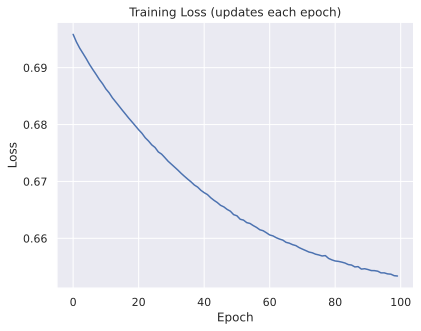

OrderedDict({'linear1.weight': tensor([[-0.1133, -0.1098, -0.0539,  ...,  0.1449,  0.1927,  0.0109],
        [ 0.0044, -0.1035,  0.1294,  ..., -0.0907, -0.1826,  0.1229],
        [-0.1309,  0.0376, -0.0430,  ..., -0.0046,  0.0786, -0.0575],
        ...,
        [ 0.0470,  0.0304,  0.1176,  ...,  0.0028, -0.1200,  0.1275],
        [-0.1095, -0.0112, -0.0309,  ...,  0.0095,  0.1042, -0.0620],
        [-0.1233,  0.0755,  0.0842,  ..., -0.0467,  0.0640,  0.0889]]), 'linear1.bias': tensor([ 0.1241, -0.1173, -0.0450, -0.0677,  0.0831,  0.1183, -0.0218, -0.0859,
         0.0207, -0.0017,  0.0563,  0.0136,  0.0706,  0.0217, -0.0832,  0.0812,
         0.0632, -0.0083, -0.0515, -0.0980, -0.0192, -0.0034,  0.0798,  0.0682,
         0.0028,  0.1162,  0.0963,  0.0178,  0.1295,  0.1079, -0.0463,  0.0801,
        -0.0123, -0.0476, -0.0942,  0.1007,  0.1091, -0.0833,  0.1107,  0.0267,
        -0.1345, -0.1009,  0.0874,  0.0384,  0.1118,  0.0428, -0.1274,  0.1232,
        -0.0148,  0.0803,  0.0524, -0.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
plotter = LiveLossPlot()
model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 100, plotter)

This was out problem. 100 epochs was not enough epocs there is still .6 loss and it has not converged yet. Lets look at it again for 300 and see if it is doing any better.

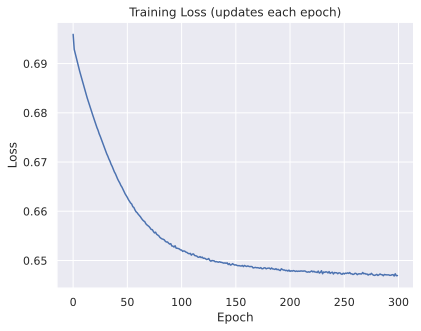

OrderedDict({'linear1.weight': tensor([[ 0.1318,  0.0768, -0.0227,  ..., -0.0421,  0.1094, -0.0575],
        [ 0.0543, -0.0461,  0.0352,  ..., -0.0229, -0.0099, -0.0722],
        [-0.0237, -0.0327, -0.0955,  ..., -0.1370, -0.1796,  0.0274],
        ...,
        [-0.1217,  0.1340, -0.0754,  ...,  0.0493, -0.0308, -0.0935],
        [-0.0875,  0.0827,  0.0144,  ..., -0.0607,  0.1357,  0.0382],
        [-0.0012, -0.0938,  0.0466,  ...,  0.0305, -0.0553, -0.1300]]), 'linear1.bias': tensor([ 0.0341,  0.0896,  0.0514, -0.0326,  0.0904,  0.0894,  0.0274, -0.1277,
        -0.0178,  0.0363, -0.0718, -0.1059,  0.1223, -0.0436,  0.0572, -0.0585,
        -0.1211,  0.1029,  0.0972,  0.1202, -0.1060, -0.0414, -0.0454,  0.0074,
        -0.0625, -0.1143, -0.0749,  0.0861, -0.0715,  0.0226, -0.0121, -0.0037,
        -0.0256, -0.0710,  0.0278,  0.0719,  0.1096, -0.1059,  0.0276, -0.0599,
         0.1178, -0.1181,  0.0045,  0.0311,  0.0981,  0.0727,  0.0032, -0.0412,
         0.0776, -0.0032, -0.0039, -0.

In [ ]:
model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 300, plotter)

This is much better and seems to be converging close to 300. It still doesn't seem to be convering all the way though. I ran it for 800 epochs and it continued going down as well. After waiting for the 800 epochs to converge I realized that I should use a larger learning rate as to help it converge faster, so we are now trying the learning rate of .01 to see if it converges any faster/if it becomes more accurate.

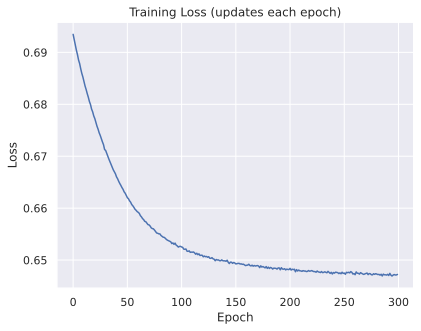

OrderedDict({'linear1.weight': tensor([[ 0.0889,  0.0865, -0.1006,  ..., -0.0619, -0.0334, -0.0980],
        [-0.0359,  0.0551,  0.0087,  ...,  0.1286, -0.0667, -0.0061],
        [ 0.0823,  0.1060,  0.1273,  ...,  0.0060, -0.1423, -0.0873],
        ...,
        [-0.0967,  0.0801,  0.0303,  ...,  0.0178,  0.1998,  0.0095],
        [ 0.1234,  0.0623, -0.1252,  ...,  0.1027,  0.0644,  0.0803],
        [-0.0743,  0.0609, -0.0840,  ..., -0.0599, -0.1827,  0.0521]]), 'linear1.bias': tensor([ 0.0232, -0.0477,  0.0097,  0.0601,  0.0993, -0.1056, -0.0953, -0.0162,
         0.0680,  0.1178, -0.0392,  0.1089,  0.0034,  0.0225, -0.0047, -0.0543,
        -0.1144,  0.0003,  0.0589, -0.0983, -0.1010,  0.1073,  0.0932, -0.0931,
        -0.0219, -0.0757,  0.0669,  0.0259,  0.0145, -0.0428, -0.0902, -0.0274,
         0.0991, -0.0572,  0.0154, -0.0494, -0.1221, -0.1056, -0.0924, -0.1099,
         0.1092, -0.0714, -0.0683,  0.0352, -0.0880,  0.0813,  0.0059, -0.0093,
         0.1031, -0.1117, -0.0723,  0.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 300, plotter)

This did converge faster and produce a better result. I then increased the epochs to 500 and let it converge.

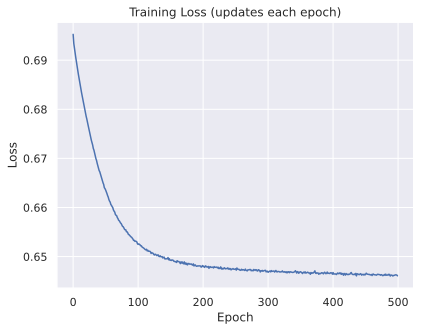

OrderedDict({'linear1.weight': tensor([[ 0.0737, -0.1489,  0.0108,  ...,  0.0674,  0.1540,  0.0366],
        [ 0.0383,  0.0314,  0.1224,  ...,  0.1073, -0.1283, -0.0128],
        [-0.1056, -0.1050, -0.0832,  ..., -0.1290,  0.0972, -0.1415],
        ...,
        [-0.0807, -0.0358,  0.0973,  ...,  0.1247, -0.1174,  0.0406],
        [-0.0386,  0.1492, -0.0191,  ...,  0.0043, -0.1251, -0.0202],
        [-0.1265, -0.1044, -0.1167,  ..., -0.0034, -0.1037,  0.1156]]), 'linear1.bias': tensor([-0.1006, -0.0005, -0.0546, -0.0654, -0.0198, -0.0198,  0.0678,  0.0005,
         0.1007, -0.0952,  0.0742, -0.0674,  0.0200,  0.1136,  0.0482, -0.0515,
         0.0584, -0.0017,  0.0140,  0.0388,  0.0470,  0.0471, -0.0445,  0.1031,
        -0.0345, -0.0147,  0.1343, -0.0195,  0.0122, -0.1158,  0.1101,  0.0771,
         0.1286,  0.0326, -0.0418,  0.0494,  0.0601,  0.0209,  0.0347, -0.0173,
        -0.1042, -0.0810, -0.0323,  0.0718,  0.0734,  0.1302,  0.0246, -0.0632,
         0.0933,  0.0993,  0.1288, -0.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 500, plotter)

It again improved. At this point I decided to try increasing the learning rate again to see if it would converge faster than it is right now.

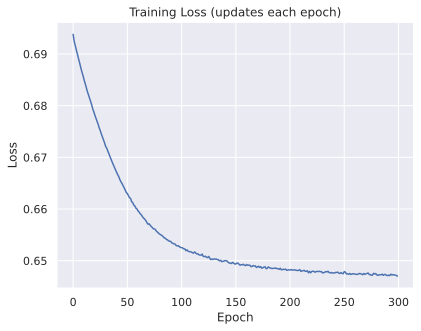

OrderedDict({'linear1.weight': tensor([[-0.0884,  0.0642,  0.1150,  ..., -0.0839, -0.1397, -0.0009],
        [-0.0740, -0.0648,  0.1328,  ...,  0.0955,  0.0563, -0.0048],
        [ 0.0935,  0.0709, -0.1228,  ...,  0.0909,  0.1021, -0.1393],
        ...,
        [-0.0942, -0.0956,  0.1352,  ...,  0.0601,  0.1208, -0.0463],
        [ 0.0439,  0.1100, -0.0300,  ..., -0.0234, -0.0825, -0.1139],
        [ 0.0285,  0.0457, -0.0965,  ...,  0.0708,  0.1300, -0.1271]]), 'linear1.bias': tensor([-0.0060, -0.1181,  0.0127, -0.0686,  0.0011,  0.0883,  0.0237, -0.0700,
         0.0293,  0.1173, -0.0701,  0.0297,  0.0316, -0.0486, -0.0015,  0.0501,
        -0.0915,  0.1111, -0.1168, -0.0202, -0.1099, -0.1273, -0.0282,  0.1183,
         0.0270, -0.0964,  0.0090,  0.0815,  0.0923, -0.1125, -0.1068, -0.0014,
        -0.0231, -0.0196, -0.0596, -0.1240,  0.0116, -0.0359,  0.1232,  0.0761,
         0.0138,  0.1145,  0.0927,  0.0514, -0.0343,  0.1049, -0.0163, -0.0461,
         0.0477,  0.0223,  0.0484, -0.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.1, weight_decay=1e-4)

model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 300, plotter)

After letting it run and it still being less than the .01 with less epochs I decided that this is as good as I realistically could do. My theory is that these would converge given enough epochs, but right now increasing the learning rate and the epochs is no longer making much of a difference. I belive that once it converges it will be close to if nor more than logistic regression...but I do not have hours to let these things train.

Only after finishing the report did I realize that I never changed it back to ReLU. So I will now switch it back and run those again...however I am not going to write over the old ones because these take forever to converge and I don't want to have to wait for them all over again and risk that they are worse.

In [ ]:
import torch.nn as nn

class UFCNN(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()

        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Sigmoid()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x

In [ ]:
plotter = LiveLossPlot()


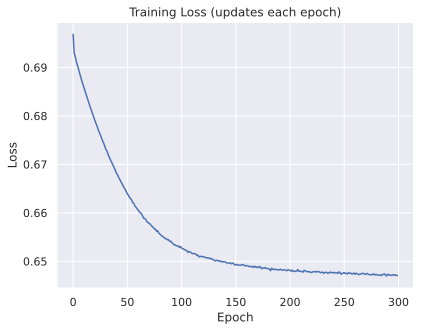

OrderedDict({'linear1.weight': tensor([[ 0.0183, -0.1197, -0.0002,  ...,  0.0378,  0.0436, -0.0357],
        [ 0.1173, -0.0933, -0.0723,  ..., -0.0180, -0.0906,  0.0469],
        [ 0.0763,  0.0740,  0.1250,  ...,  0.0191,  0.0574,  0.0798],
        ...,
        [-0.0374, -0.0648, -0.0802,  ..., -0.1184,  0.1088,  0.0167],
        [-0.0145,  0.0549, -0.0636,  ...,  0.0465, -0.0230,  0.1161],
        [-0.1330, -0.1039, -0.0242,  ..., -0.1084,  0.1230,  0.0547]]), 'linear1.bias': tensor([-0.1209, -0.0694, -0.0373,  0.1232, -0.1165,  0.0065,  0.1349, -0.0531,
        -0.1135, -0.0423,  0.0311, -0.0533, -0.0410,  0.0837,  0.0053,  0.0947,
        -0.0428,  0.0972, -0.1293, -0.0345,  0.0632,  0.0512,  0.0268, -0.1075,
        -0.1065, -0.0156,  0.0319, -0.1098,  0.1246, -0.1014, -0.0687, -0.0588,
        -0.1038,  0.0806, -0.1293,  0.0700, -0.1170,  0.0782,  0.0318,  0.0218,
         0.0413,  0.0355,  0.1257,  0.1311,  0.1159, -0.0569, -0.1183,  0.0621,
         0.0256,  0.0896,  0.1127,  0.

In [ ]:
model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 300, plotter)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 300, plotter)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

model, baseline_train_accuracy, baseline_train_precision, baseline_train_recall, train_data_loader, test_data_loader = runNN(cummulative_df, 500, plotter)

This did not help either. So in conclusion, I can make a model that will predict the correct winner 62.75% of the time with a NN and 63% of the time with Logistic Regression. Both of these are above the baseline of always choosing the red fighter (57%) but worse than always choosing favored figher. It is unusual that the NN would be less than the LR model...however I believe that if I had enough time to let the model converge, it would eventually catch up to the LR model.

